# 📊 **TelecomX - Análise de Evasão de Clientes**
#### ***Challenge Data Science | Alura + Oracle Next Education (ONE)***

- 👤 **Autor:** Lucas Rodrigues
- 📅 **Data:** 01 de Março de 2026
- 🔗 **Repositório:** GitHub - telecomx-churn-analysis
- 🎯 **Objetivo:** Análise de churn com o objetivo de identificar os fatores que influenciam a evasão de clientes, por meio de processos de ETL e Análise Exploratória de Dados (EDA), como etapa preparatória para a construção de modelos preditivos.

---
### 📌 **Sobre este Projeto**

Este notebook documenta a análise de dados de evasão de clientes (churn) da empresa TelecomX, desenvolvido como parte do desafio *(Challenge)* de Data Science da Alura.

> **Etapas do projeto:**

- 📥 **Extract** - Extração de dados 
- 🔧 **Transform** - Limpeza e transformação dos dados
- 💾 **Load** - Carga dos dados tratados
- 📊 **EDA** - Análise Exploratória de Dados
- 💡 **Insights** - Recomendações estratégicas

---
___
### 🏢 **CONTEXTO DO NEGÓCIO**


 Como análista de dados na ***Telecom X***, farei parte do projeto **"Churn de Clientes"**. A empresa enfrenta um alto índice de cancelamentos e precisa entender os fatores que levam à perda de clientes.

 Meu desafio será **coletar, tratar e analisar os dados**, utilizando Python e suas principais bibliotecas para extrair insights valiosos. A partir da minha análise, os demais colegas da equipe de Data Science poderam avançar para modelos preditivos e desenvolver estratégias para reduzir a evasão

---
### 📊 **DICIONÁRIO DE DADOS**

#### 🎯 Variável Alvo

- `evasao` *(Churn)*: Indica se o cliente cancelou o serviço.
  - `1` → Cliente evadiu
  - `0` → Cliente permaneceu

#### 👤 Perfil Demográfico

- `genero` *(gender)*: Gênero do cliente.
- `idoso` *(SeniorCitizen)*: Indica se o cliente possui idade igual ou superior a 65 anos.
- `possui_parceiro` *(Partner)*: Indica se o cliente possui parceiro(a).
- `possui_dependentes` *(Dependents)*: Indica se o cliente possui dependentes.



#### 📅 Tempo de Relacionamento

- `tempo_permanencia` *(tenure)*: Quantidade de meses de contrato do cliente.



#### 📞 Serviços de Telefonia

- `servico_telefone` *(PhoneService)*: Indica se o cliente possui serviço telefônico.
- `multiplas_linhas` *(MultipleLines)*: Indica se o cliente possui múltiplas linhas telefônicas.



#### 🌐 Serviços de Internet

- `tipo_internet` *(InternetService)*: Tipo de serviço de internet contratado.
- `seguranca_online` *(OnlineSecurity)*: Assinatura adicional de segurança online.
- `backup_online` *(OnlineBackup)*: Assinatura adicional de backup online.
- `protecao_dispositivo` *(DeviceProtection)*: Assinatura adicional de proteção de dispositivo.
- `suporte_tecnico` *(TechSupport)*: Assinatura adicional de suporte técnico.
- `streaming_tv` *(StreamingTV)*: Assinatura de TV.
- `streaming_filmes` *(StreamingMovies)*: Assinatura de streaming de filmes.



#### 📄 Informações Contratuais

- `tipo_contrato` *(Contract)*: Tipo de contrato do cliente.
- `fatura_digital` *(PaperlessBilling)*: Indica se o cliente prefere receber fatura digital.
- `metodo_pagamento` *(PaymentMethod)*: Forma de pagamento utilizada.


#### 💰 Informações Financeiras

- `cobranca_mensal` *(Charges.Monthly)*: Valor mensal cobrado pelos serviços.
- `cobranca_total` *(Charges.Total)*: Valor total gasto pelo cliente ao longo do contrato.
- `cobranca_diaria`: Valor médio diário estimado com base na cobrança mensal.



---
### 📌 **Nota sobre Tradução**

Seguindo recomendação dos instrutores da Alura, todas as colunas foram traduzidas para português para:

- ✅ Ajudar a compreensão e manutenção do código
- ✅ Tornar apresentações mais legiveis
- ✅ Preparar para modelagem de dados em português (se necessário)



___
### 📦 **DEPENDÊNCIAS DO PROJETO**

| Biblioteca   | Versão   |
|-------------|----------|
| matplotlib  | 3.10.8   |
| numpy       | 2.4.2    |
| seaborn     | 0.13.2   |
| pandas      | 3.0.1    |

In [535]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<div align="center">

<h3><b>⭐ Resumo Completo no final do Projeto ⭐</b></h3>

</div>

___
## 📥 **Extracão De Dados**

- Importando a base de dados que será analisada nesse projeto, fase de extração do arquivo ``.json``. Importante para analisar como os dados estão formatados

**Fonte:** https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json

In [536]:
dados = pd.read_json('TelecomX_Data.json')
dados

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [537]:
colunas = list(dados.columns)
colunas

['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']

In [538]:
for c in colunas[2:]:
    print(c, dados[c].apply(len).unique())

customer [5]
phone [2]
internet [7]
account [4]


## 📚 **Tratamento de Dados**

Usando o ``json_normalize`` para estruturar os dados em DataFrames tabulares

A fase de tratamento dos dados requer a separação e normalização dos dados das colunas do arquivo importado em formato ``.json``. São quatro colunas de dados agrupados que serão separadas em quatro Dataframes:

- ``customer``
- ``phone``
- ``internet``
- ``account``

E então, reúni-los em um único DataFrame uniforme, junto a variável alvo ``churn``. 


#### 📂 Dataframe da coluna ``customer``



In [539]:
customer = pd.json_normalize(dados['customer'])
customer

,gender,SeniorCitizen,Partner,Dependents,tenure
0,Female,0,Yes,Yes,9
1,Male,0,No,No,9
2,Male,0,No,No,4
3,Male,1,Yes,No,13
4,Female,1,Yes,No,3
...,...,...,...,...,...
7262,Female,0,No,No,13
7263,Male,0,Yes,No,22
7264,Male,0,No,No,2
7265,Male,0,Yes,Yes,67


#### 📂 Dataframe da coluna ``phone``

In [540]:
phone = pd.json_normalize(dados['phone'])
phone

,PhoneService,MultipleLines
0,Yes,No
1,Yes,Yes
2,Yes,No
3,Yes,No
4,Yes,No
...,...,...
7262,Yes,No
7263,Yes,Yes
7264,Yes,No
7265,Yes,No


#### 📂 Dataframe da coluna ``internet``

In [541]:
internet = pd.json_normalize(dados['internet'])
internet

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,DSL,No,Yes,No,Yes,Yes,No
1,DSL,No,No,No,No,No,Yes
2,Fiber optic,No,No,Yes,No,No,No
3,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,Fiber optic,No,No,No,Yes,Yes,No
...,...,...,...,...,...,...,...
7262,DSL,Yes,No,No,Yes,No,No
7263,Fiber optic,No,No,No,No,No,Yes
7264,DSL,No,Yes,No,No,No,No
7265,DSL,Yes,No,Yes,Yes,No,Yes


#### 📂 Dataframe da coluna ``account``


In [542]:
account = pd.json_normalize(dados['account'])
account

,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,One year,Yes,Mailed check,65.60,593.3
1,Month-to-month,No,Mailed check,59.90,542.4
2,Month-to-month,Yes,Electronic check,73.90,280.85
3,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...
7262,One year,No,Mailed check,55.15,742.9
7263,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,Month-to-month,Yes,Mailed check,50.30,92.75
7265,Two year,No,Mailed check,67.85,4627.65


#### 📁 Criando o Dataframe concatenado com as colunas normalizadas



In [543]:
dados_prontos = pd.concat(
    [dados['Churn'], customer, phone, internet, account], axis=1
)

In [544]:
dados_prontos.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


### ✏️ Padronizando os nomes das colunas para letras minúsculas.

- A padronizacao das colunas é uma **boa prática** para a manipulação das colunas ao longo da análise. 

- Ao converter todos os nomes para letras minúsculas, eu **evito inconsistências** causadas por diferenças de capitalização e tornamos o código **mais limpo e reprodutível**.

In [545]:
dados_prontos.columns = dados_prontos.columns.str.lower().str.replace('.','')
dados_prontos.columns

Index(['churn', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'chargesmonthly', 'chargestotal'],
      dtype='str')

In [546]:
dados_prontos.head()

,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,chargesmonthly,chargestotal
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


### 🔎 Verificando a natureza dos dados na categoria de serviços

- Nesta etapa, analisarei as informações relacionadas à categoria de serviços presentes no conjunto de dados. 

- A intensão é **compreender** a estrutura, os **tipos de variáveis**, identificar **inconsistências**, **valores ausentes** e limpar, se necessario, dados nulos.


In [547]:
dados_prontos.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   churn             7267 non-null   str    
 1   gender            7267 non-null   str    
 2   seniorcitizen     7267 non-null   int64  
 3   partner           7267 non-null   str    
 4   dependents        7267 non-null   str    
 5   tenure            7267 non-null   int64  
 6   phoneservice      7267 non-null   str    
 7   multiplelines     7267 non-null   str    
 8   internetservice   7267 non-null   str    
 9   onlinesecurity    7267 non-null   str    
 10  onlinebackup      7267 non-null   str    
 11  deviceprotection  7267 non-null   str    
 12  techsupport       7267 non-null   str    
 13  streamingtv       7267 non-null   str    
 14  streamingmovies   7267 non-null   str    
 15  contract          7267 non-null   str    
 16  paperlessbilling  7267 non-null   str    
 17  paymen

In [548]:
dados_prontos['streamingmovies'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [549]:
dados_prontos['streamingtv'].unique()


<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [550]:
dados_prontos['techsupport'].unique()


<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [551]:
dados_prontos['onlinesecurity'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [552]:
dados_prontos['multiplelines'].unique()


<StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str

In [553]:
dados_prontos['onlinebackup'].unique()


<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [554]:
dados_prontos['deviceprotection'].unique()


<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [555]:
dados_prontos['chargestotal'].isnull().sum()

np.int64(0)

In [556]:
dados_prontos['chargestotal'] = dados_prontos['chargestotal'].fillna(
    dados_prontos['chargesmonthly'] * dados_prontos['tenure'],
    inplace=True
)

C:\Users\User\AppData\Local\Temp\ipykernel_14084\1139390149.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dados_prontos['chargestotal'] = dados_prontos['chargestotal'].fillna(


### ⚒️ Tratamento de Inconsistências nos Dados

- Nesta etapa, são identificadas e tratadas **inconsistências** presentes no conjunto de dados, como valores com **caracteres de espaço**, **registros incorretos** ou **formatos inadequados** 

- O objetivo é garantir maior qualidade e confiabilidade aos dados antes das etapas de análise e modelagem.

Primeiro nas colunas "Categóricas":

- ``gender``
- ``interneservice``
- ``contract``
- ``paperlessbilling``
- ``paymentmethod``

Segundo nas colunas "Booleanas":

- ``churn``
- ``onlinebackup``
- ``streamingmovies``
- ``streamingtv``
- ``techsupport``
- ``onlinesecurity``
- ``multiplelines``
- ``deviceprotection``
- ``paperlessbilling``
- ``partner``
- ``dependents``
- ``phoneservice``



>#### Colunas categoricas

In [557]:
colunas_categoricas = ['gender', 'internetservice', 'contract', 'paperlessbilling', 'paymentmethod']

In [558]:
dados_prontos[colunas_categoricas] = dados_prontos[colunas_categoricas].apply(lambda col: col.str.lower())

In [559]:
dados_prontos[colunas_categoricas] = dados_prontos[colunas_categoricas].apply(lambda col: col.str.replace('-', '_').replace(r"\b\s+\b",'_', regex=True))

In [560]:
dados_prontos

,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,chargesmonthly,chargestotal
0,No,female,0,Yes,Yes,9,Yes,No,dsl,No,Yes,No,Yes,Yes,No,one_year,yes,mailed_check,65.60,593.3
1,No,male,0,No,No,9,Yes,Yes,dsl,No,No,No,No,No,Yes,month_to_month,no,mailed_check,59.90,542.4
2,Yes,male,0,No,No,4,Yes,No,fiber_optic,No,No,Yes,No,No,No,month_to_month,yes,electronic_check,73.90,280.85
3,Yes,male,1,Yes,No,13,Yes,No,fiber_optic,No,Yes,Yes,No,Yes,Yes,month_to_month,yes,electronic_check,98.00,1237.85
4,Yes,female,1,Yes,No,3,Yes,No,fiber_optic,No,No,No,Yes,Yes,No,month_to_month,yes,mailed_check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,No,female,0,No,No,13,Yes,No,dsl,Yes,No,No,Yes,No,No,one_year,no,mailed_check,55.15,742.9
7263,Yes,male,0,Yes,No,22,Yes,Yes,fiber_optic,No,No,No,No,No,Yes,month_to_month,yes,electronic_check,85.10,1873.7
7264,No,male,0,No,No,2,Yes,No,dsl,No,Yes,No,No,No,No,month_to_month,yes,mailed_check,50.30,92.75
7265,No,male,0,Yes,Yes,67,Yes,No,dsl,Yes,No,Yes,Yes,No,Yes,two_year,no,mailed_check,67.85,4627.65


> #### Colunas booleanas

In [561]:
colunas_bool = ['churn','onlinebackup', 'streamingmovies', 'streamingtv', 
           'techsupport', 'onlinesecurity', 
           'multiplelines', 'deviceprotection','paperlessbilling',
           'partner', 'dependents', 'phoneservice' ]

In [562]:
dados_prontos.columns

Index(['churn', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'chargesmonthly', 'chargestotal'],
      dtype='str')

In [563]:
dados_prontos[colunas_bool] = dados_prontos[colunas_bool].replace(r'^No .*', 'no', regex=True).replace('Yes', 'yes').replace('No', 'no')

In [564]:
dados_prontos[colunas_bool]

,churn,onlinebackup,streamingmovies,streamingtv,techsupport,onlinesecurity,multiplelines,deviceprotection,paperlessbilling,partner,dependents,phoneservice
0,no,yes,no,yes,yes,no,no,no,yes,yes,yes,yes
1,no,no,yes,no,no,no,yes,no,no,no,no,yes
2,yes,no,no,no,no,no,no,yes,yes,no,no,yes
3,yes,yes,yes,yes,no,no,no,yes,yes,yes,no,yes
4,yes,no,no,yes,yes,no,no,no,yes,yes,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...
7262,no,no,no,no,yes,yes,no,no,no,no,no,yes
7263,yes,no,yes,no,no,no,yes,no,yes,yes,no,yes
7264,no,yes,no,no,no,no,no,no,yes,no,no,yes
7265,no,no,yes,no,yes,yes,no,yes,no,yes,yes,yes


In [565]:
dados_prontos[colunas_categoricas]

,gender,internetservice,contract,paperlessbilling,paymentmethod
0,female,dsl,one_year,yes,mailed_check
1,male,dsl,month_to_month,no,mailed_check
2,male,fiber_optic,month_to_month,yes,electronic_check
3,male,fiber_optic,month_to_month,yes,electronic_check
4,female,fiber_optic,month_to_month,yes,mailed_check
...,...,...,...,...,...
7262,female,dsl,one_year,no,mailed_check
7263,male,fiber_optic,month_to_month,yes,electronic_check
7264,male,dsl,month_to_month,yes,mailed_check
7265,male,dsl,two_year,no,mailed_check


In [566]:
dados_prontos.head()

,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,chargesmonthly,chargestotal
0,no,female,0,yes,yes,9,yes,no,dsl,no,yes,no,yes,yes,no,one_year,yes,mailed_check,65.6,593.3
1,no,male,0,no,no,9,yes,yes,dsl,no,no,no,no,no,yes,month_to_month,no,mailed_check,59.9,542.4
2,yes,male,0,no,no,4,yes,no,fiber_optic,no,no,yes,no,no,no,month_to_month,yes,electronic_check,73.9,280.85
3,yes,male,1,yes,no,13,yes,no,fiber_optic,no,yes,yes,no,yes,yes,month_to_month,yes,electronic_check,98.0,1237.85
4,yes,female,1,yes,no,3,yes,no,fiber_optic,no,no,no,yes,yes,no,month_to_month,yes,mailed_check,83.9,267.4


### ⚒️ Conversão dos tipos de dados (dtype)

- Nesta etapa, realizamos a conversão e o ajuste dos tipos de dados das variáveis para garantir que cada coluna esteja no formato mais adequado para análise. 

- A correta definição dos tipos de dados melhora a consistência do dataset e permite a aplicação correta de operações estatísticas, agregações e visualizações.

In [567]:
dados_prontos.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   churn             7267 non-null   str    
 1   gender            7267 non-null   str    
 2   seniorcitizen     7267 non-null   int64  
 3   partner           7267 non-null   str    
 4   dependents        7267 non-null   str    
 5   tenure            7267 non-null   int64  
 6   phoneservice      7267 non-null   str    
 7   multiplelines     7267 non-null   str    
 8   internetservice   7267 non-null   str    
 9   onlinesecurity    7267 non-null   str    
 10  onlinebackup      7267 non-null   str    
 11  deviceprotection  7267 non-null   str    
 12  techsupport       7267 non-null   str    
 13  streamingtv       7267 non-null   str    
 14  streamingmovies   7267 non-null   str    
 15  contract          7267 non-null   str    
 16  paperlessbilling  7267 non-null   str    
 17  paymen

In [568]:
dados_prontos.head(10)

,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,chargesmonthly,chargestotal
0,no,female,0,yes,yes,9,yes,no,dsl,no,yes,no,yes,yes,no,one_year,yes,mailed_check,65.60,593.3
1,no,male,0,no,no,9,yes,yes,dsl,no,no,no,no,no,yes,month_to_month,no,mailed_check,59.90,542.4
2,yes,male,0,no,no,4,yes,no,fiber_optic,no,no,yes,no,no,no,month_to_month,yes,electronic_check,73.90,280.85
3,yes,male,1,yes,no,13,yes,no,fiber_optic,no,yes,yes,no,yes,yes,month_to_month,yes,electronic_check,98.00,1237.85
4,yes,female,1,yes,no,3,yes,no,fiber_optic,no,no,no,yes,yes,no,month_to_month,yes,mailed_check,83.90,267.4
5,no,female,0,no,yes,9,yes,no,dsl,no,no,no,yes,yes,yes,month_to_month,yes,credit_card (automatic),69.40,571.45
6,no,female,1,yes,no,71,yes,no,fiber_optic,yes,yes,yes,yes,yes,yes,two_year,yes,bank_transfer (automatic),109.70,7904.25
7,no,male,0,yes,no,63,yes,yes,fiber_optic,yes,no,no,yes,no,no,two_year,yes,credit_card (automatic),84.65,5377.8
8,no,female,1,no,no,7,yes,no,dsl,yes,no,no,no,no,no,month_to_month,yes,electronic_check,48.20,340.35
9,no,female,0,yes,yes,65,yes,yes,dsl,yes,yes,yes,yes,yes,yes,two_year,yes,mailed_check,90.45,5957.9


In [569]:
dados_prontos['chargestotal'] = (dados_prontos['chargestotal'].str.strip())


In [570]:
dados_prontos['chargestotal'] = pd.to_numeric(dados_prontos['chargestotal'],errors='coerce')

In [571]:
colunas_category = ['internetservice', 'contract', 'paymentmethod']

In [572]:
dados_prontos[colunas_category] = dados_prontos[colunas_category].astype('category')                         

In [573]:
dados_prontos.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   churn             7267 non-null   str     
 1   gender            7267 non-null   str     
 2   seniorcitizen     7267 non-null   int64   
 3   partner           7267 non-null   str     
 4   dependents        7267 non-null   str     
 5   tenure            7267 non-null   int64   
 6   phoneservice      7267 non-null   str     
 7   multiplelines     7267 non-null   str     
 8   internetservice   7267 non-null   category
 9   onlinesecurity    7267 non-null   str     
 10  onlinebackup      7267 non-null   str     
 11  deviceprotection  7267 non-null   str     
 12  techsupport       7267 non-null   str     
 13  streamingtv       7267 non-null   str     
 14  streamingmovies   7267 non-null   str     
 15  contract          7267 non-null   category
 16  paperlessbilling  7267 non-null   s

In [574]:
colunas_bool = ['churn','partner', 'dependents', 'phoneservice', 'multiplelines', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'paperlessbilling' ]

In [575]:
dados_prontos[colunas_bool] = dados_prontos[colunas_bool].replace({'yes': True, 'no': False}).astype(np.bool)


In [576]:
dados_prontos.head()

,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,chargesmonthly,chargestotal
0,False,female,0,True,True,9,True,False,dsl,False,True,False,True,True,False,one_year,True,mailed_check,65.6,593.30
1,False,male,0,False,False,9,True,True,dsl,False,False,False,False,False,True,month_to_month,False,mailed_check,59.9,542.40
2,True,male,0,False,False,4,True,False,fiber_optic,False,False,True,False,False,False,month_to_month,True,electronic_check,73.9,280.85
3,True,male,1,True,False,13,True,False,fiber_optic,False,True,True,False,True,True,month_to_month,True,electronic_check,98.0,1237.85
4,True,female,1,True,False,3,True,False,fiber_optic,False,False,False,True,True,False,month_to_month,True,mailed_check,83.9,267.40


### 🌍 **Tradução do conteúdo do DataFrame para português**

- Nesta etapa, realizarei a tradução dos valores presentes no DataFrame para o português, com o objetivo de facilitar a interpretação e análise dos dados. 

- Essa padronização torna o conjunto de dados mais acessível para as etapas seguintes de exploração e visualização.

In [577]:
dados_prontos.columns

Index(['churn', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'chargesmonthly', 'chargestotal'],
      dtype='str')

In [578]:
dados_prontos['gender'] = dados_prontos['gender'].map({
    'male': 'masculino',
    'female': 'feminino'
})

In [579]:
dados_prontos = dados_prontos.rename(columns={
    'customerid': 'id_cliente',
    'churn': 'evasao',
    'gender': 'genero',
    'seniorcitizen': 'idoso',
    'partner': 'possui_parceiro',
    'dependents': 'possui_dependentes',
    'tenure': 'tempo_permanencia',
    'phoneservice': 'servico_telefone',
    'multiplelines': 'multiplas_linhas',
    'internetservice': 'tipo_internet',
    'onlinesecurity': 'seguranca_online',
    'onlinebackup': 'backup_online',
    'deviceprotection': 'protecao_dispositivo',
    'techsupport': 'suporte_tecnico',
    'streamingtv': 'streaming_tv',
    'streamingmovies': 'streaming_filmes',
    'contract': 'tipo_contrato',
    'paperlessbilling': 'fatura_digital',
    'paymentmethod': 'metodo_pagamento',
    'chargesmonthly': 'cobranca_mensal',
    'chargestotal': 'cobranca_total'
})

#### 📝 Traduzindo dados da coluna ``tipo_internet``

In [580]:
dados_prontos['tipo_internet'] = dados_prontos['tipo_internet'].astype(str)

dados_prontos['tipo_internet'] = dados_prontos['tipo_internet'].replace({
    'dsl': 'dsl',
    'fiber_optic': 'fibra_optica',
    'no': 'sem_internet'
})

#### 📝 Traduzindo dados da coluna ``tipo_contato``

In [581]:
dados_prontos['tipo_contrato'] = dados_prontos['tipo_contrato'].astype(str)

dados_prontos['tipo_contrato'] = dados_prontos['tipo_contrato'].replace({
    'month_to_month': 'mensal',
    'one_year': 'anual',
    'two_year': 'bienal'
})

#### 📝 Traduzindo dados da coluna ``metodo_pagamento``

In [582]:
dados_prontos['metodo_pagamento'] = dados_prontos['metodo_pagamento'].astype(str)

dados_prontos['metodo_pagamento'] = dados_prontos['metodo_pagamento'].replace({
    'electronic_check': 'cheque_eletronico',
    'mailed_check': 'cheque_correio',
    'bank_transfer (automatic)': 'transferencia_bancaria_automatica',
    'credit_card (automatic)': 'cartao_credito_automatico'
})

In [583]:
dados_prontos.head()

,evasao,genero,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total
0,False,feminino,0,True,True,9,True,False,dsl,False,True,False,True,True,False,anual,True,cheque_correio,65.6,593.30
1,False,masculino,0,False,False,9,True,True,dsl,False,False,False,False,False,True,mensal,False,cheque_correio,59.9,542.40
2,True,masculino,0,False,False,4,True,False,fibra_optica,False,False,True,False,False,False,mensal,True,cheque_eletronico,73.9,280.85
3,True,masculino,1,True,False,13,True,False,fibra_optica,False,True,True,False,True,True,mensal,True,cheque_eletronico,98.0,1237.85
4,True,feminino,1,True,False,3,True,False,fibra_optica,False,False,False,True,True,False,mensal,True,cheque_correio,83.9,267.40


### 🔨 Criação da coluna ``cobranca_diaria``

- Essa coluna ajudará a aprofundar sua análise e fornecer informações valiosas para as próximas etapas.

In [584]:
dados_prontos['cobranca_diaria'] = round(dados_prontos['cobranca_mensal'] / 30, 2)

In [585]:
dados_prontos.head()

,evasao,genero,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,cobranca_diaria
0,False,feminino,0,True,True,9,True,False,dsl,False,...,False,True,True,False,anual,True,cheque_correio,65.6,593.30,2.19
1,False,masculino,0,False,False,9,True,True,dsl,False,...,False,False,False,True,mensal,False,cheque_correio,59.9,542.40,2.00
2,True,masculino,0,False,False,4,True,False,fibra_optica,False,...,True,False,False,False,mensal,True,cheque_eletronico,73.9,280.85,2.46
3,True,masculino,1,True,False,13,True,False,fibra_optica,False,...,True,False,True,True,mensal,True,cheque_eletronico,98.0,1237.85,3.27
4,True,feminino,1,True,False,3,True,False,fibra_optica,False,...,False,True,True,False,mensal,True,cheque_correio,83.9,267.40,2.80


In [586]:
dados_prontos.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   evasao                7267 non-null   bool   
 1   genero                7267 non-null   str    
 2   idoso                 7267 non-null   int64  
 3   possui_parceiro       7267 non-null   bool   
 4   possui_dependentes    7267 non-null   bool   
 5   tempo_permanencia     7267 non-null   int64  
 6   servico_telefone      7267 non-null   bool   
 7   multiplas_linhas      7267 non-null   bool   
 8   tipo_internet         7267 non-null   str    
 9   seguranca_online      7267 non-null   bool   
 10  backup_online         7267 non-null   bool   
 11  protecao_dispositivo  7267 non-null   bool   
 12  suporte_tecnico       7267 non-null   bool   
 13  streaming_tv          7267 non-null   bool   
 14  streaming_filmes      7267 non-null   bool   
 15  tipo_contrato         7267 non-n

###  ⭐ **EXTRA** - **Padronização e Transformação dos Dados para Machine Learning**

- Nesta etapa, realizarei a padronização e transformação dos dados com o objetivo de prepará-los para a aplicação de modelos para a equipe de Machine Learning. 
- Esse processo inclui ajustes de formato, codificação de variáveis categóricas e adequação das variáveis numéricas, garantindo que o conjunto de dados esteja estruturado de forma adequada para o treinamento dos modelos.

In [587]:
dados_normalizados_ml = dados_prontos.copy()

In [588]:
binarias = [
    'evasao',
    'idoso',
    'possui_parceiro',
    'possui_dependentes',
    'servico_telefone',
    'multiplas_linhas',
    'seguranca_online',
    'backup_online',
    'protecao_dispositivo',
    'suporte_tecnico',
    'streaming_tv',
    'streaming_filmes',
    'fatura_digital'
]

In [589]:
categoricas = [
    'genero',
    'tipo_internet',
    'tipo_contrato',
    'metodo_pagamento',
]

In [590]:
dados_normalizados_ml[binarias] = (dados_normalizados_ml[binarias].replace(
    {True: 1, False: 0
}).astype(np.int64))

### **One-Hot Encoding**

- O **`One-Hot Encoding`** é uma técnica para transformar variáveis categóricas (strings ou objetos) em colunas numéricas binárias (0 ou 1).
- Cada categoria vira uma coluna separada, com 1 se o registro pertence à categoria e 0 caso contrário.
- Essa transformação evita ordens implícitas que poderiam confundir algoritmos de **Machine Learning** 

In [591]:
dados_normalizados_ml = pd.get_dummies(
    dados_normalizados_ml,
    columns=categoricas,
    drop_first=True
)

In [592]:
dados_normalizados_ml['faixa_permanencia'] = pd.cut(
    dados_normalizados_ml['tempo_permanencia'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 meses', '13-24 meses',
            '25-48 meses', '49-72 meses'],
    include_lowest=True
).astype('category')

In [593]:
dados_normalizados_ml = pd.get_dummies(
    dados_normalizados_ml,
    columns=['faixa_permanencia']
)

In [594]:
dados_normalizados_ml = dados_normalizados_ml.replace(
    {True: 1, False: 0})

In [595]:
dados_normalizados_ml.head()

,evasao,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,tipo_internet_sem_internet,tipo_contrato_bienal,tipo_contrato_mensal,metodo_pagamento_cheque_correio,metodo_pagamento_cheque_eletronico,metodo_pagamento_transferencia_bancaria_automatica,faixa_permanencia_0-12 meses,faixa_permanencia_13-24 meses,faixa_permanencia_25-48 meses,faixa_permanencia_49-72 meses
0,0,0,1,1,9,1,0,0,1,0,...,0,0,0,1,0,0,1,0,0,0
1,0,0,0,0,9,1,1,0,0,0,...,0,0,1,1,0,0,1,0,0,0
2,1,0,0,0,4,1,0,0,0,1,...,0,0,1,0,1,0,1,0,0,0
3,1,1,1,0,13,1,0,0,1,1,...,0,0,1,0,1,0,0,1,0,0
4,1,1,1,0,3,1,0,0,0,0,...,0,0,1,1,0,0,1,0,0,0


In [597]:
dados_normalizados_ml.to_csv('dados_normalizados_ml.csv', index=False)

---

## 🔎 **Análise descritiva**

- Nesta etapa, realizarei uma análise descritiva do conjunto de dados com o objetivo de compreender suas principais características. 
- São exploradas medidas estatísticas, distribuições e padrões presentes nas variáveis, permitindo uma visão inicial do comportamento dos dados antes de análises mais aprofundadas.

In [598]:
dados_prontos.head()

,evasao,genero,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,cobranca_diaria
0,False,feminino,0,True,True,9,True,False,dsl,False,...,False,True,True,False,anual,True,cheque_correio,65.6,593.30,2.19
1,False,masculino,0,False,False,9,True,True,dsl,False,...,False,False,False,True,mensal,False,cheque_correio,59.9,542.40,2.00
2,True,masculino,0,False,False,4,True,False,fibra_optica,False,...,True,False,False,False,mensal,True,cheque_eletronico,73.9,280.85,2.46
3,True,masculino,1,True,False,13,True,False,fibra_optica,False,...,True,False,True,True,mensal,True,cheque_eletronico,98.0,1237.85,3.27
4,True,feminino,1,True,False,3,True,False,fibra_optica,False,...,False,True,True,False,mensal,True,cheque_correio,83.9,267.40,2.80


In [599]:
dados_prontos.tail()

,evasao,genero,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,cobranca_diaria
7262,False,feminino,0,False,False,13,True,False,dsl,True,...,False,True,False,False,anual,False,cheque_correio,55.15,742.90,1.84
7263,True,masculino,0,True,False,22,True,True,fibra_optica,False,...,False,False,False,True,mensal,True,cheque_eletronico,85.10,1873.70,2.84
7264,False,masculino,0,False,False,2,True,False,dsl,False,...,False,False,False,False,mensal,True,cheque_correio,50.30,92.75,1.68
7265,False,masculino,0,True,True,67,True,False,dsl,True,...,True,True,False,True,bienal,False,cheque_correio,67.85,4627.65,2.26
7266,False,masculino,0,True,True,63,False,False,dsl,True,...,True,False,True,True,bienal,False,cheque_eletronico,59.00,3707.60,1.97


In [600]:
dados_prontos.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   evasao                7267 non-null   bool   
 1   genero                7267 non-null   str    
 2   idoso                 7267 non-null   int64  
 3   possui_parceiro       7267 non-null   bool   
 4   possui_dependentes    7267 non-null   bool   
 5   tempo_permanencia     7267 non-null   int64  
 6   servico_telefone      7267 non-null   bool   
 7   multiplas_linhas      7267 non-null   bool   
 8   tipo_internet         7267 non-null   str    
 9   seguranca_online      7267 non-null   bool   
 10  backup_online         7267 non-null   bool   
 11  protecao_dispositivo  7267 non-null   bool   
 12  suporte_tecnico       7267 non-null   bool   
 13  streaming_tv          7267 non-null   bool   
 14  streaming_filmes      7267 non-null   bool   
 15  tipo_contrato         7267 non-n

In [601]:
dados_prontos.shape

(7267, 21)

In [602]:
dados_prontos.describe()

,idoso,tempo_permanencia,cobranca_mensal,cobranca_total,cobranca_diaria
count,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213,2.157292
std,0.369074,24.571773,30.129572,2268.632997,1.004407
min,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,9.000000,35.425000,400.225000,1.180000
50%,0.000000,29.000000,70.300000,1391.000000,2.340000
75%,0.000000,55.000000,89.875000,3785.300000,2.995000
max,1.000000,72.000000,118.750000,8684.800000,3.960000


In [603]:
dados_prontos.describe(include='O')

C:\Users\User\AppData\Local\Temp\ipykernel_14084\2698344504.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dados_prontos.describe(include='O')


,genero,tipo_internet,tipo_contrato,metodo_pagamento
count,7267,7267,7267,7267
unique,2,3,3,4
top,masculino,fibra_optica,mensal,cheque_eletronico
freq,3675,3198,4005,2445


# 📉 **Entendendo a distribuição da evasão**

- Neste passo, o objetivo é compreender como a variável “churn” (evasão) está distribuída entre os clientes.

- Para isso, utilizarei visualizações gráficas que permitem observar a proporção de clientes que permaneceram na empresa em comparação com aqueles que cancelaram o serviço.



In [604]:
dados_prontos['evasao'].value_counts()

evasao
False    5398
True     1869
Name: count, dtype: int64

In [605]:
clientes_evadidos = dados_prontos.loc[dados_prontos['evasao']]
clientes_evadidos

,evasao,genero,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,cobranca_diaria
2,True,masculino,0,False,False,4,True,False,fibra_optica,False,...,True,False,False,False,mensal,True,cheque_eletronico,73.90,280.85,2.46
3,True,masculino,1,True,False,13,True,False,fibra_optica,False,...,True,False,True,True,mensal,True,cheque_eletronico,98.00,1237.85,3.27
4,True,feminino,1,True,False,3,True,False,fibra_optica,False,...,False,True,True,False,mensal,True,cheque_correio,83.90,267.40,2.80
18,True,masculino,1,False,False,45,True,False,dsl,True,...,True,False,False,True,anual,False,cartao_credito_automatico,62.70,2791.50,2.09
19,True,masculino,1,False,False,1,False,False,dsl,False,...,False,False,False,False,mensal,True,cheque_eletronico,25.10,25.10,0.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7243,True,masculino,1,False,False,21,True,False,fibra_optica,False,...,True,False,True,True,mensal,True,transferencia_bancaria_automatica,96.80,2030.30,3.23
7246,True,masculino,1,False,False,9,True,True,fibra_optica,False,...,False,False,False,True,mensal,True,cheque_eletronico,83.85,790.15,2.80
7260,True,feminino,0,False,False,1,True,False,fibra_optica,False,...,False,False,False,False,mensal,True,cheque_correio,70.15,70.15,2.34
7261,True,feminino,0,False,False,4,True,False,sem_internet,False,...,False,False,False,False,mensal,False,transferencia_bancaria_automatica,20.95,85.50,0.70


In [606]:
proporcao = dados_prontos['evasao'].value_counts(normalize=True) * 100 
proporcao

evasao
False    74.280996
True     25.719004
Name: proportion, dtype: float64

### 📊 Visualização gráfica dos dados

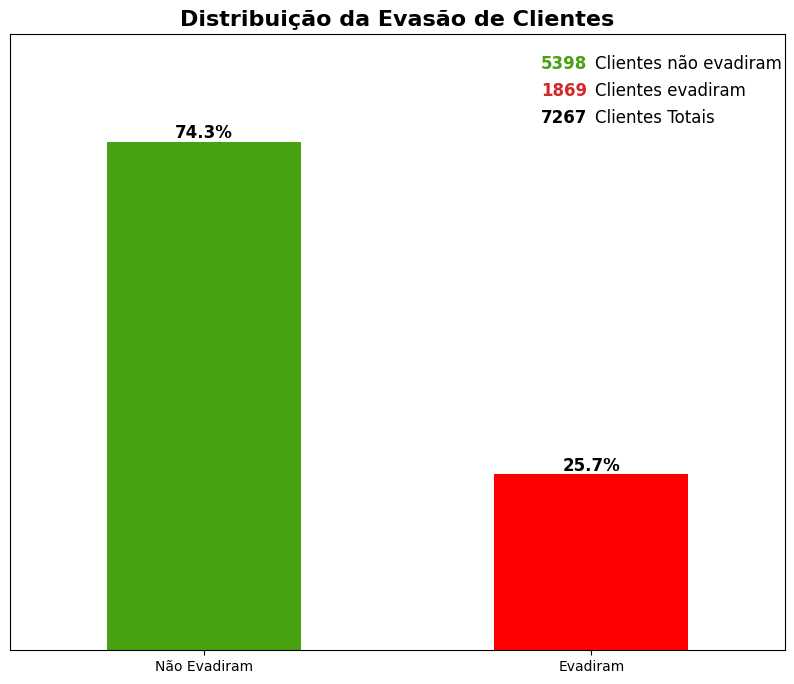

In [607]:
COLOR = ['#48A111', 'red']

ticks = {
    False: 'Não Evadiram',
    True: 'Evadiram'
}

ax = proporcao.plot(kind='bar', color=COLOR, figsize=(10, 8))

for i, v in enumerate(proporcao):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize= 12)

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição da Evasão de Clientes', fontweight= 'bold', fontsize= 16)
plt.xlabel('')
plt.ylabel('')
plt.yticks([])

# Mede o comprimento da coluna vertical
min_val = 0
max_val = 100
plt.yticks(np.arange(min_val, max_val, 10))

plt.text(0.87 , 85, "5398", color="#48A111", fontweight="bold", fontsize=12)
plt.text(1.01, 85, "Clientes não evadiram", fontsize=12,)

plt.text(0.87, 81, "1869", color="#D62728", fontweight="bold", fontsize=12)
plt.text(1.01, 81, "Clientes evadiram", fontsize=12)

plt.text(0.87, 77, "7267", color="black", fontweight="bold", fontsize=12)
plt.text(1.01, 77, "Clientes Totais", fontsize=12)

ax.set_xticklabels([ticks[i] for i in proporcao.index], rotation=0)
ax.get_yaxis().set_visible(False)

plt.show()

### **Insight**

Dada essa informação estratégica, mensurei a quantidade distributiva das evasões e os dados entregaram que **25,7%** dos clientes da **``TelecomX``** **evadiram**.
Essa métrica é essencial para a solução da necessidade desse projeto, porque o compreendimento desses dados e a tomada de decisão estratégica para o negócio fica direcionada exclusivamente a essa proporção de clientes.

### **Distribuição de Evasão por Variáveis Categóricas**

- Agora, vou explorar como a **evasão** se comporta de acordo com variáveis categóricas, como ``gênero``, ``tipo de contrato``, ``método de pagamento``, entre outras.

- Essa análise pode revelar padrões interessantes, como, por exemplo, se clientes de determinados perfis têm maior tendência a cancelar o serviço, o que ajudará a direcionar ações estratégicas.

#### **Análise de evasão por ``tipo_servico``**

In [608]:
clientes_evadidos.head()

,evasao,genero,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,cobranca_diaria
2,True,masculino,0,False,False,4,True,False,fibra_optica,False,...,True,False,False,False,mensal,True,cheque_eletronico,73.9,280.85,2.46
3,True,masculino,1,True,False,13,True,False,fibra_optica,False,...,True,False,True,True,mensal,True,cheque_eletronico,98.0,1237.85,3.27
4,True,feminino,1,True,False,3,True,False,fibra_optica,False,...,False,True,True,False,mensal,True,cheque_correio,83.9,267.40,2.80
18,True,masculino,1,False,False,45,True,False,dsl,True,...,True,False,False,True,anual,False,cartao_credito_automatico,62.7,2791.50,2.09
19,True,masculino,1,False,False,1,False,False,dsl,False,...,False,False,False,False,mensal,True,cheque_eletronico,25.1,25.10,0.84


In [609]:
dt_cliente_evasao = (clientes_evadidos['tipo_internet'].value_counts())
dt_cliente_evasao

tipo_internet
fibra_optica    1297
dsl              459
sem_internet     113
Name: count, dtype: int64

In [610]:
clientes_evadidos['tipo_internet'].value_counts(normalize=True) * 100

tipo_internet
fibra_optica    69.395399
dsl             24.558587
sem_internet     6.046014
Name: proportion, dtype: float64

### 📊 Visualização gráfica dos dados

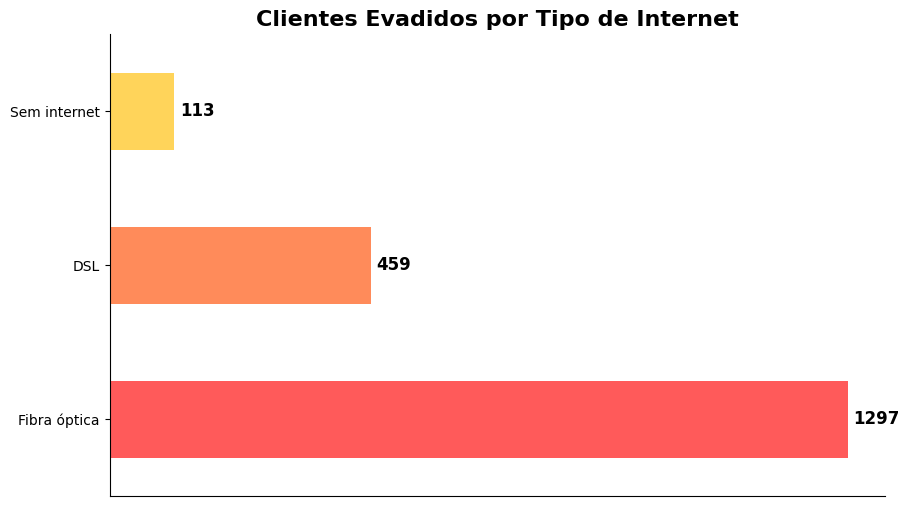

In [611]:
dt_cliente_evasao = clientes_evadidos['tipo_internet'].value_counts()

COLOR = ['#FF5A5A', '#FF8B5A', '#FFD45A']

ticks = {
    'sem_internet': 'Sem internet',
    'dsl': 'DSL',
    'fibra_optica': 'Fibra óptica'
}

ax = dt_cliente_evasao.plot(kind='barh', color=COLOR, figsize=(10,6))

for i, v in enumerate(dt_cliente_evasao):
    ax.text(v + 10, i, f'{v}', va='center', fontweight='bold', fontsize=12)

plt.title('Clientes Evadidos por Tipo de Internet', fontweight='bold', fontsize=16)

# pegar apenas o segundo nível do índice (tipo_internet)
ax.set_yticklabels([ticks[i] for i in dt_cliente_evasao.index])

ax.get_xaxis().set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('')
plt.ylabel('')


plt.show()

#### **Insight**

Do total de **1869** clientes que evadiram, **1297** clientes ou **``69.3%``** tinham contratado o serviço de **Fibra óptica**, seguido do serviço de **DSL** com **459** clientes ou **``24.5%``** do total e por último, **113** ou 6,1% dos clientes que evadiram mas que não possuiam um serviço de internet.

Esses números indicam possivelmente algum tipo de insatisfação com os respectivos serviços, principalmente com o serviço de **Fibra óptica** com a maior distribuição dos dados de evasão.

Porém, antes de determinar essa hipótese, quais outros ângulos dos dados poderiam ser explorados para esclarecer melhor as evasões?

#### **Análise de evasão por ``tipo_contrato``**

In [612]:
evasao_cliente_contrato = clientes_evadidos['tipo_contrato'].value_counts().sort_values(ascending=True)
evasao_cliente_contrato

tipo_contrato
bienal      48
anual      166
mensal    1655
Name: count, dtype: int64

In [613]:
clientes_evadidos['tipo_contrato'].value_counts(normalize=True) * 100

tipo_contrato
mensal    88.550027
anual      8.881755
bienal     2.568218
Name: proportion, dtype: float64

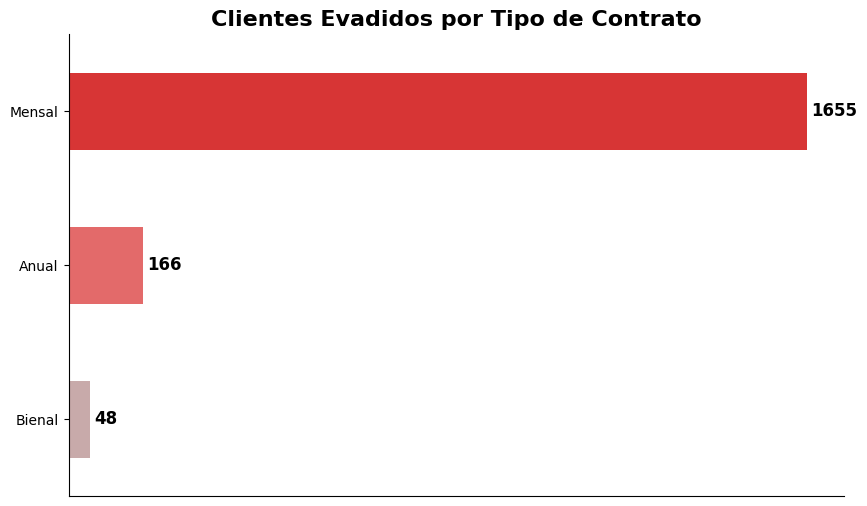

In [614]:
COLOR = ['#C8AAAA', '#E36A6A', '#D73535']

ticks = {
    'mensal': 'Mensal',
    'anual': 'Anual',
    'bienal': 'Bienal'
}

ax = evasao_cliente_contrato.plot(kind='barh', color=COLOR, figsize=(10,6))

for i, v in enumerate(evasao_cliente_contrato):
    ax.text(v + 10, i, f'{v}', va='center', fontweight='bold', fontsize=12)

plt.title('Clientes Evadidos por Tipo de Contrato', fontweight='bold', fontsize=16)

# pegar apenas o segundo nível do índice (tipo_internet)
ax.set_yticklabels([ticks[i] for i in evasao_cliente_contrato.index])

ax.get_xaxis().set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('')
plt.ylabel('')


plt.show()

### **Insight**

São **1655** clientes ou **``88,5%``** de evasões por contratos mensais, esse indicador é um forte indicio de fragilidade do plano mensal em reter clientes, visto que os planos **anuais** e **bienais** coletam uma parcela relativamente minúscula dos dados de evasões com **``8,8%``** e **``2,5%``** respectivamente.

As evasões estão concentradas principalmente nos planos mensais, reforçando a relação entre o tipo de contrato e a propensão à evasão.



### Impacto financeiro da evasão por ``tipo_contrato``

In [615]:
perda_financeira = clientes_evadidos.groupby('tipo_contrato')['cobranca_total'].sum().sort_values(ascending=True)
perda_financeira

tipo_contrato
bienal     260753.45
anual      674991.20
mensal    1927182.25
Name: cobranca_total, dtype: float64

In [616]:
perda_financeira_total = clientes_evadidos.groupby('tipo_contrato')['cobranca_total'].sum().sum()
print(f'R$ {perda_financeira_total:,.2f}')

R$ 2,862,926.90


In [617]:
clientes_evadidos['cobranca_total'].sum()

np.float64(2862926.9000000004)

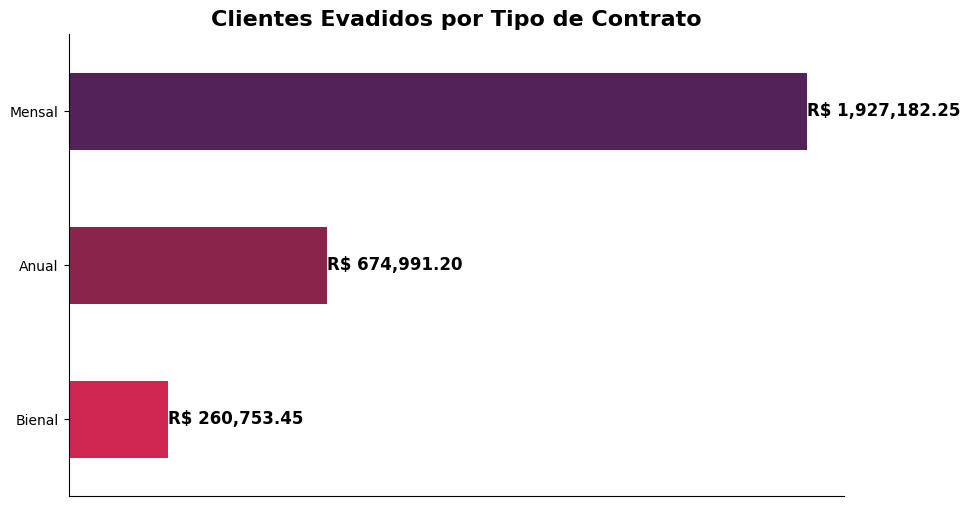

In [618]:
COLOR = ['#D02752', '#8A244B', '#522258']

ticks = {
    'mensal': 'Mensal',
    'anual': 'Anual',
    'bienal': 'Bienal'
}

ax = perda_financeira.plot(kind='barh', color=COLOR,figsize=(10,6))

for i, v in enumerate(perda_financeira):
    ax.text(v + 10, i, f'R$ {v:,.2f}', va='center', fontweight='bold', fontsize=12)

plt.title('Clientes Evadidos por Tipo de Contrato', fontweight='bold', fontsize=16)

# pegar apenas o segundo nível do índice (tipo_internet)
ax.set_yticklabels([ticks[i] for i in perda_financeira.index])

ax.get_xaxis().set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('')
plt.ylabel('')

plt.show()

#### **Insight**

O impacto das taxas dessas evasões refletem uma perda financeira expressiva, com a somatória total de R$ 2,862,926.90

Ou seja, **``88,5%``** das evasões por planos mensais, refletem R$ 1,927,182.25 de perda.

Reforçando a necessidade de avaliar as razões que faz o plano mensal ter tanta negatividade financeira.

---

#### **Análise de evasão por ``genero``**

In [619]:
evasao_genero = clientes_evadidos['genero'].value_counts()
evasao_genero

genero
feminino     939
masculino    930
Name: count, dtype: int64

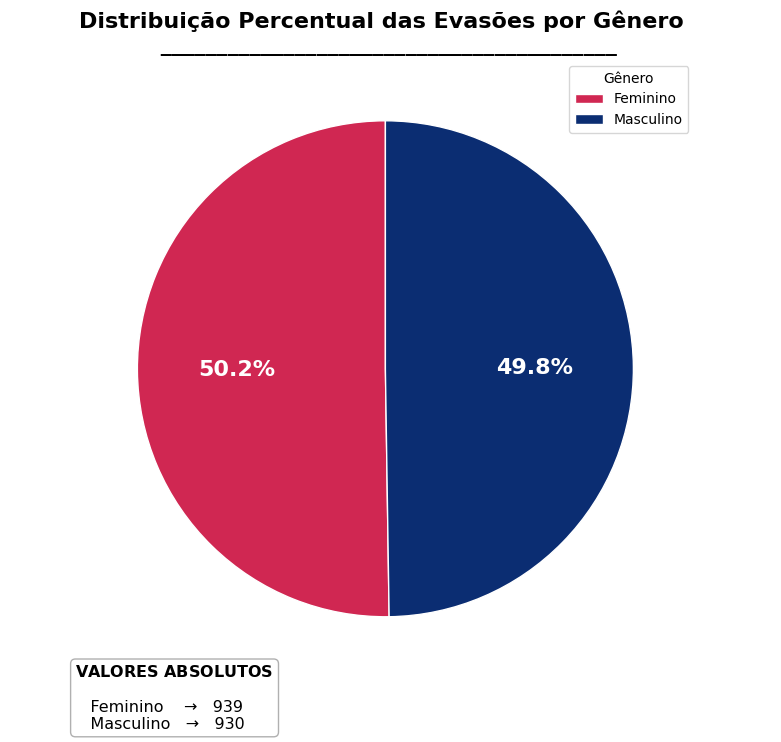

In [620]:
# config de tamanho do grafico
fig, ax = plt.subplots(figsize=(8,18))

labels = {
    'masculino' : 'Masculino',
    'feminino' : 'Feminino'
}

colors = {
    'masculino' : '#0B2D72',
    'feminino' : '#D02752'
}

# Visual de pizza
evasao_genero.plot(
    kind='pie',
    labels = [labels[i] for i in evasao_genero.index],
    ax=ax,
    startangle=90,
    autopct='%1.1f%%',
    colors= [colors[i] for i in evasao_genero.index],
    pctdistance=0.6,      # posição da porcentagem
    labeldistance=1.05,   # posição do rótulo
    wedgeprops={'edgecolor':'white','linewidth':1},
    textprops={'fontsize':16,
               'fontweight': 'bold',
               'color' : 'white'},
)

ax.set_title(
    'Distribuição Percentual das Evasões por Gênero \n _________________________________________',
    fontsize=16,
    weight='bold'
)

texto_anotacao = r"$\bf{VALORES\ ABSOLUTOS}$"  "\n\n""   Feminino    →   939 \n   Masculino   →   930"

ax.annotate(
    texto_anotacao,
    xy=(1, 0.9),          # ponto da pizza
    xytext=(-1.25, -1.4525),      # posição da caixa de texto
    fontsize=11.5,
    color="#000000",
    bbox=dict(
        boxstyle="round,pad=0.3",
        edgecolor='#B0B0B0',
        facecolor='white'
    )
    
)

ax.set_ylabel('')  # remove label lateral
plt.legend(loc='upper right', title='Gênero')
plt.show()

#### **Insight**

Um fato curioso na caracterização dos dados da ``TelecomX`` é que a distribuição das evasões por gênero estão divididas em praticamente **``50%``** para âmbos os lados.

Essa igualdade dificulta a interpretação e a identificação de padrões que apoiem novas hipóteses sobre as evasões.

Portanto, a variável **gênero** não é um bom preditor de evasões para este caso.

#### **Análise de evasão por ``senioridade``**

In [621]:
perda_financeira_senior = clientes_evadidos.groupby('idoso')['cobranca_total'].sum()
perda_financeira_senior

idoso
0    1980521.75
1     882405.15
Name: cobranca_total, dtype: float64

In [622]:
evasao_senior = clientes_evadidos['idoso'].value_counts()
evasao_senior

idoso
0    1393
1     476
Name: count, dtype: int64

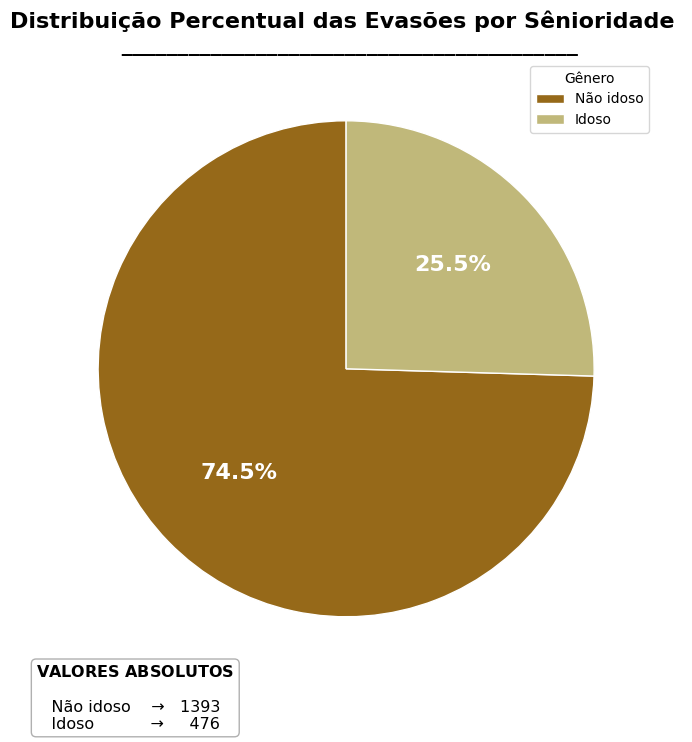

In [623]:
# config de tamanho do grafico
fig, ax = plt.subplots(figsize=(8,18))

labels = {
    0: 'Não idoso',
    1: 'Idoso'
}


colors = {
    0 : '#966919',
    1 : '#C0B87A'
}

# Visual de pizza
evasao_senior.plot(
    kind='pie',
    labels = [labels[i] for i in evasao_senior.index],
    ax=ax,
    startangle=90,
    autopct='%1.1f%%',
    colors= [colors[i] for i in evasao_senior.index],
    pctdistance=0.6,      # posição da porcentagem
    labeldistance=1.05,   # posição do rótulo
    wedgeprops={'edgecolor':'white','linewidth':1},
    textprops={'fontsize':16,
               'fontweight': 'bold',
               'color' : 'white'},
)

ax.set_title(
    'Distribuição Percentual das Evasões por Sênioridade \n _________________________________________',
    fontsize=16,
    weight='bold'
)

texto_anotacao = r"$\bf{VALORES\ ABSOLUTOS}$"  "\n\n""   Não idoso    →   1393 \n   Idoso           →     476"

ax.annotate(
    texto_anotacao,
    xy=(1, 0.9),          # ponto da pizza
    xytext=(-1.25, -1.4525),      # posição da caixa de texto
    fontsize=11.5,
    color="#000000",
    bbox=dict(
        boxstyle="round,pad=0.3",
        edgecolor='#B0B0B0',
        facecolor='white'
    )
    
)

ax.set_ylabel('')  # remove label lateral
plt.legend(loc='upper right', title='Gênero')
plt.show()

### **Insight**

Diferentemente da variável de **gênero**, a análise da evasão por **sênioridade** apresentou uma distribuição mais informativa.

Observa-se que **``74,5%``** das evasões são de clientes não idosos, enquanto **``25,5%``** correspondem a clientes com `**60 anos ou mais.**`

Esse resultado indica que a maior parte dos cancelamentos está concentrada entre clientes**`` abaixo de 60 anos``**. No entanto, para avaliar se esse grupo realmente apresenta maior propensão à evasão, seria necessário comparar essas proporções com a distribuição total de clientes por **faixa etária**.

Como esta informação não está presente na base de dados da ``TelecomX``. vou considerar que os clientes ``abaixo de 60 anos`` tem alta frequência de evasão em comparação com clientes da maior idade.

Ainda assim, essa análise contribui para orientar futuras investigações sobre o perfil dos clientes mais associados a evasão.

#### **Análise de evasão por estrutura familiar (``possui_dependentes`` e ``possui_parceiro``)**

In [624]:
dependentes_evasao = clientes_evadidos['possui_dependentes'].value_counts()
dependentes_evasao

possui_dependentes
False    1543
True      326
Name: count, dtype: int64

In [625]:
parceiro_evasao = clientes_evadidos['possui_parceiro'].value_counts()
parceiro_evasao

possui_parceiro
False    1200
True      669
Name: count, dtype: int64

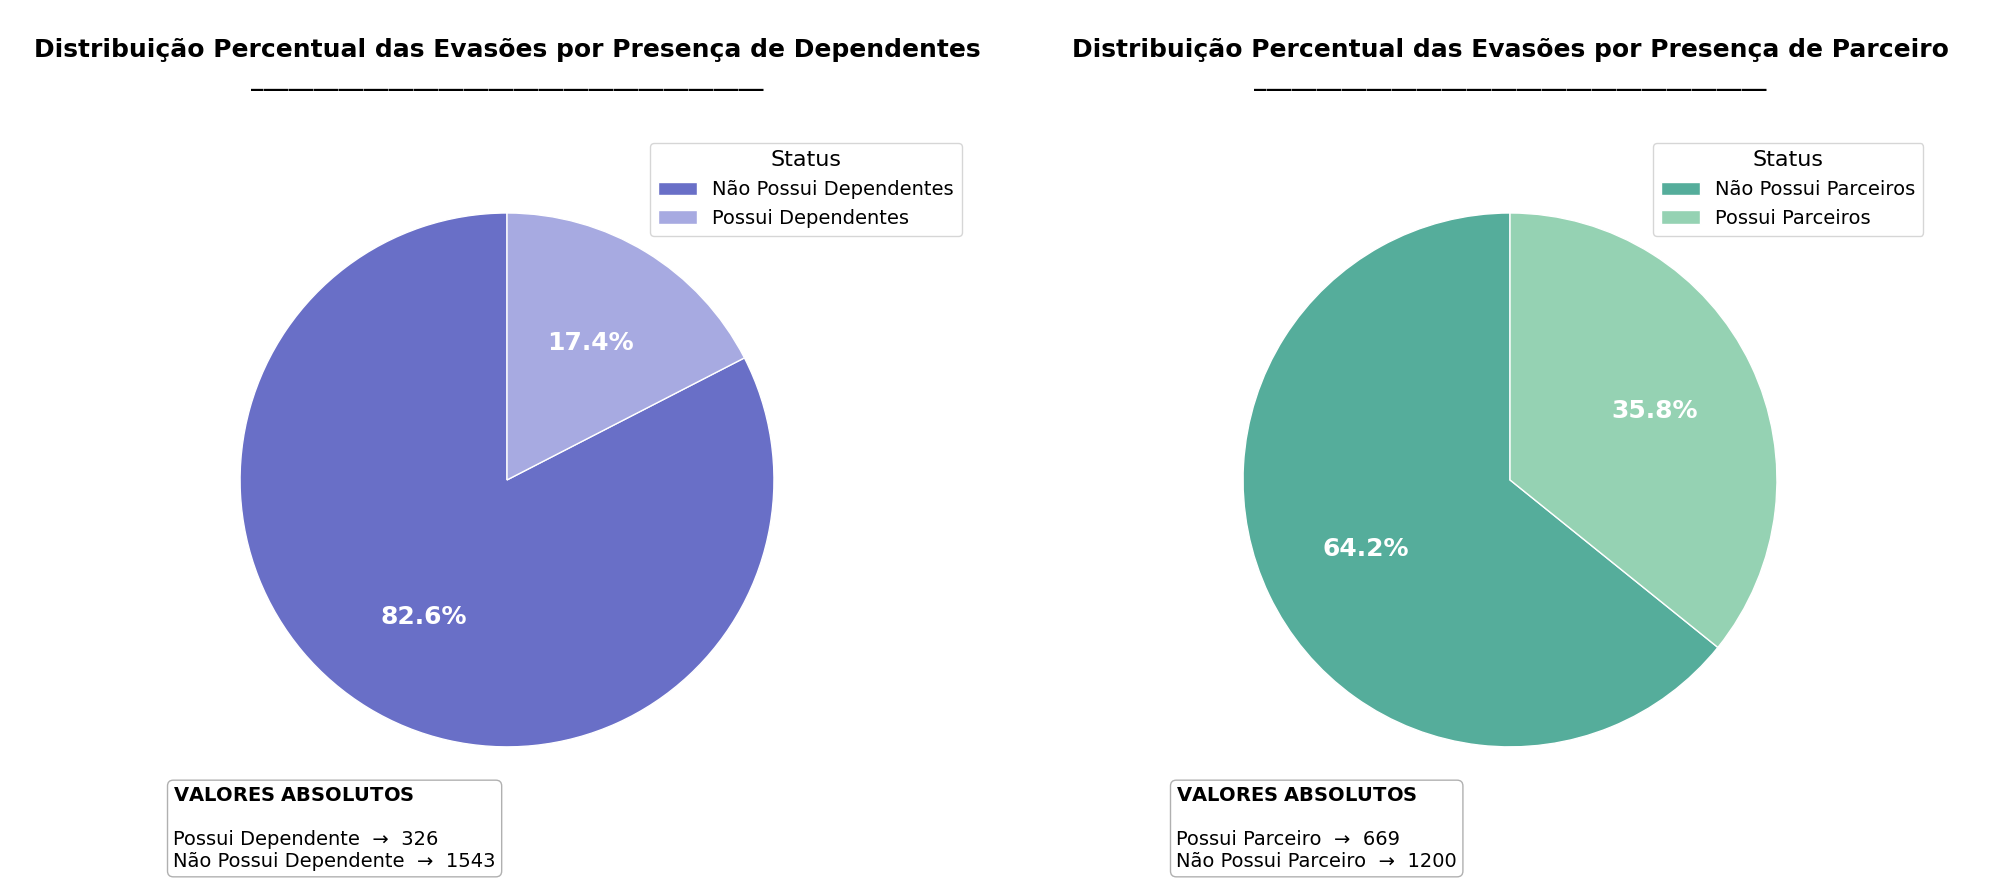

In [626]:
fig, ax = plt.subplots(1, 2, figsize=(20, 14))

labels = {
    False: 'Não Possui Dependentes',
    True: 'Possui Dependentes'
}

colors = {
    False: '#696FC7',
    True: '#A7AAE1'
}

# ----------------------
# GRÁFICO DE PIZZA
# ----------------------
dependentes_evasao.plot(
    kind='pie',
    labels=[labels[i] for i in dependentes_evasao.index],
    ax=ax[0],
    startangle=90,
    autopct='%1.1f%%',
    colors=[colors[i] for i in dependentes_evasao.index],
    pctdistance=0.6,
    labeldistance=1.05,
    wedgeprops={'edgecolor':'white','linewidth':1},
    textprops={
        'fontsize':18,
        'fontweight':'bold',
        'color':'white'
    }
)

ax[0].set_title(
    '\nDistribuição Percentual das Evasões por Presença de Dependentes\n_________________________________________',
    fontsize=18,
    weight='bold',
    y=1.08
)

texto_anotacao = (
    r"$\bf{VALORES\ ABSOLUTOS}$"
    "\n\nPossui Dependente  →  326"
    "\nNão Possui Dependente  →  1543"
)

ax[0].annotate(
    texto_anotacao,
    xy=(1, 0.9),
    xytext=(-1.25, -1.45),
    fontsize=14,
    color="#000000",
    bbox=dict(
        boxstyle="round,pad=0.3",
        edgecolor='#B0B0B0',
        facecolor='white'
    )
)

ax[0].set_ylabel('')
ax[0].legend(loc='upper left', 
             title='Status', 
             fontsize=14, 
             title_fontsize=16,
             bbox_to_anchor=(0.7, 1.02)
)

# ----------------------
# SEGUNDO GRÁFICO (exemplo)
# ----------------------
labels = {
    False: 'Não Possui Parceiros',
    True: 'Possui Parceiros'
}

colors = {
    False: '#55AD9B',
    True: '#95D2B3'
}
# ----------------------
# GRÁFICO DE PIZZA
# ----------------------
parceiro_evasao.plot(
    kind='pie',
    labels=[labels[i] for i in parceiro_evasao.index],
    ax=ax[1],
    startangle=90,
    autopct='%1.1f%%',
    colors=[colors[i] for i in parceiro_evasao.index],
    pctdistance=0.6,
    labeldistance=1.05,
    wedgeprops={'edgecolor':'white','linewidth':1},
    textprops={
        'fontsize':18,
        'fontweight':'bold',
        'color':'white'
    }
)

ax[1].set_title(
    '\nDistribuição Percentual das Evasões por Presença de Parceiro\n_________________________________________',
    fontsize=18,
    weight='bold',
    y=1.08
)

texto_anotacao = (
    r"$\bf{VALORES\ ABSOLUTOS}$"
    "\n\nPossui Parceiro  →  669"
    "\nNão Possui Parceiro  →  1200"
)

ax[1].annotate(
    texto_anotacao,
    xy=(1, 0.9),
    xytext=(-1.25, -1.45),
    fontsize=14,
    color="#000000",
    bbox=dict(
        boxstyle="round,pad=0.3",
        edgecolor='#B0B0B0',
        facecolor='white'
    )
)

ax[1].set_ylabel('')
ax[1].legend(loc='upper left', 
             title='Status', 
             fontsize=14, 
             title_fontsize=16,
             bbox_to_anchor=(0.7, 1.02)
)
plt.tight_layout()
plt.show()

#### **Insight**

Ao investigar o perfil dos clientes, observa-se que a distribuição das evasões entre clientes sem dependentes é significativamente maior em relação aos que possuem dependentes.

Do total de evasões, **``82,6%``** (**1543 clientes**) correspondem a clientes que não possuem dependentes, enquanto **``17,4%``** (**326 clientes**) pertencem a clientes que possuem dependentes.

De forma semelhante, **``64,2%``** das evasões ocorrem entre clientes que não possuem parceiros.

Esses resultados indicam uma possível associação entre características familiares e o comportamento de evasão. No entanto, para confirmar se esses fatores realmente aumentam a propensão ao churn, seria necessário comparar essas proporções com a distribuição total de clientes nesses grupos.

#### **Análise de evasão pelo conjunto de serviços (``servico_telefone``, `multiplas_linhas`, ``seguranca_online``, ``backup_online``, ``protecao_dispositivo``, ``suporte_tecnico``, ``streaming_tv``, ``streaming_filmes``)**

In [627]:
servicos = ['servico_telefone', 'multiplas_linhas', 'seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv',
           'streaming_filmes']

In [628]:
clientes_evadidos['seguranca_online']

2       False
3       False
4       False
18       True
19      False
        ...  
7243    False
7246    False
7260    False
7261    False
7263    False
Name: seguranca_online, Length: 1869, dtype: bool

In [629]:
evasao_servico = clientes_evadidos[servicos].sum().sort_values(ascending=True)
evasao_servico

seguranca_online         295
suporte_tecnico          310
backup_online            523
protecao_dispositivo     545
streaming_tv             814
streaming_filmes         818
multiplas_linhas         850
servico_telefone        1699
dtype: int64

In [630]:
evasao_pct = clientes_evadidos[servicos].mean().round(3) * 100
evasao_pct.sort_values()

seguranca_online        15.8
suporte_tecnico         16.6
backup_online           28.0
protecao_dispositivo    29.2
streaming_tv            43.6
streaming_filmes        43.8
multiplas_linhas        45.5
servico_telefone        90.9
dtype: float64

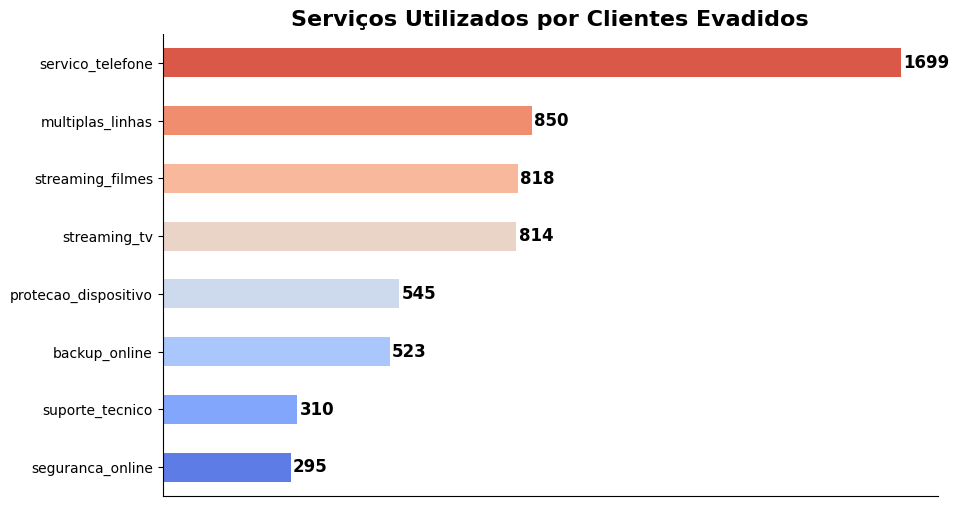

In [631]:
CORES = sns.color_palette("coolwarm", len(evasao_servico))

# renomear serviços antes do gráfico
evasao_plot = evasao_servico.rename(index=ticks)

ax = evasao_plot.plot(
    kind='barh',
    color=CORES,
    figsize=(10,6)
)

for i, v in enumerate(evasao_plot):
    ax.text(
        v + 5,
        i,
        f'{v}',
        va='center',
        fontweight='bold',
        fontsize=12
    )

plt.title(
    'Serviços Utilizados por Clientes Evadidos',
    fontweight='bold',
    fontsize=16
)

ax.get_xaxis().set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('')
plt.ylabel('')

plt.show()

### **Insight**

A análise da distribuição das evasões por tipo de serviço apresenta quais serviços estavam contratados entre os 1869 clientes que cancelaram seus contratos.

Portanto, na maioria dos clientes que evadiram:

- **`90,9%`** ou **1699** tinham contrato com o serviço de telefone
- **``45.5%``** ou **850** tinham contrato com o serviço de multiplas linhas
- **``43.8%``** ou **818** tinham contrato com o serviço de streaming de filmes
- **``43.6%``** ou **814** tinham contrato com o serviço de streaming de tv
- **``29.2%``** ou **545** tinham contrato com o serviço de protecao do dispositivo
- **``28.0%``** ou **523** tinham contrato com o serviço de backup online
- **``16.6%``** ou **310** tinham contrato com o serviço de suporte técnico
- **``15.8%``** ou **295** tinham contrato com o serviço de segurança online

A alta presença do serviço de telefone entre os clientes evadidos pode estar relacionada à grande proporção de clientes da base que possuem esse serviço. Por outro lado, serviços como suporte técnico e segurança online aparecem com menor frequência entre os clientes que cancelaram, o que pode indicar uma possível relação desses serviços com a retenção de clientes.

---

#### **Análise de evasão por ``metodo_pagamento``**

In [632]:
pagamento_evasao = clientes_evadidos['metodo_pagamento'].value_counts(normalize=True).sort_values(ascending=True)
pagamento_evasao

metodo_pagamento
cartao_credito_automatico            0.124131
transferencia_bancaria_automatica    0.138042
cheque_correio                       0.164794
cheque_eletronico                    0.573034
Name: proportion, dtype: float64

In [633]:
pagamento_evasao = clientes_evadidos['metodo_pagamento'].value_counts().sort_values(ascending=True)
pagamento_evasao

metodo_pagamento
cartao_credito_automatico             232
transferencia_bancaria_automatica     258
cheque_correio                        308
cheque_eletronico                    1071
Name: count, dtype: int64

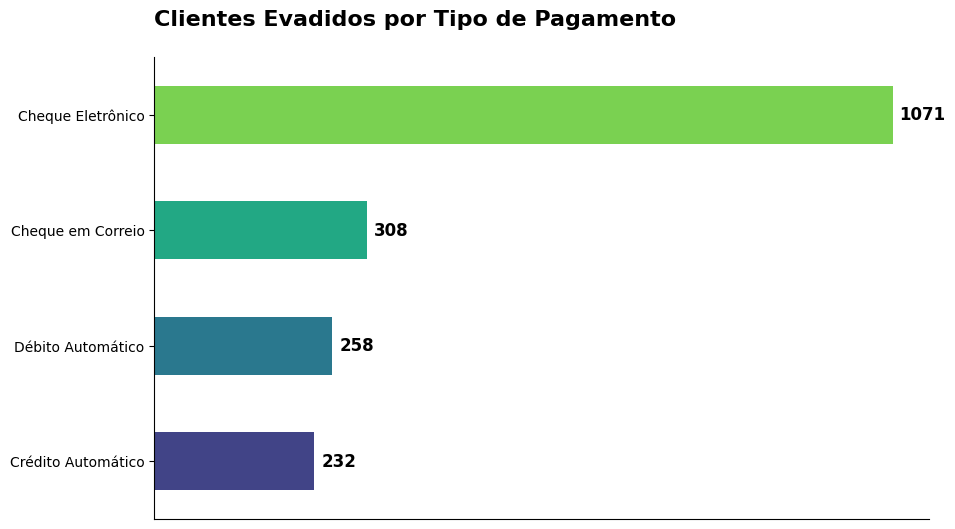

In [634]:
COLOR = sns.color_palette('viridis', 4)

ticks = {
    'cheque_eletronico': 'Cheque Eletrônico',
    'cheque_correio': 'Cheque em Correio',
    'transferencia_bancaria_automatica': 'Débito Automático',
    'cartao_credito_automatico': 'Crédito Automático'
}

ax = pagamento_evasao.plot(kind='barh', color=COLOR, figsize=(10,6))

for i, v in enumerate(pagamento_evasao):
    ax.text(v + 10, i, f'{v}', va='center', fontweight='bold', fontsize=12)

plt.title('Clientes Evadidos por Tipo de Pagamento\n', fontweight='bold', fontsize=16, loc='left')

# pegar apenas o segundo nível do índice (tipo_internet)
ax.set_yticklabels([ticks[i] for i in pagamento_evasao.index])

ax.get_xaxis().set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('')
plt.ylabel('')


plt.show()

### **Insight**

A análise da distribuição das evasões por método de pagamento mostra que a maior parte dos cancelamentos ocorre entre clientes que utilizam cheque eletrônico, representando **``57,3%``** (**1071 ocorrências**) das evasões.

Em seguida aparecem os pagamentos por cheque enviado por correio, com **``16,7%``** (**308 ocorrências**), débito automático, com **``13,8%``** (**258 ocorrências**), e crédito automático, com **``12,4%``** (**232 ocorrências**).

Esses resultados indicam uma forte concentração de evasões entre clientes que utilizam cheque eletrônico como forma de pagamento.

---

### **Distribuição de Evasão por Variáveis Numéricas**

Neste passo, explorarei como variáveis numéricas, como "``total gasto``" ou "``tempo de contrato``", se distribuem entre clientes que cancelaram (evasão) e os que não cancelaram.

Essa análise ajuda a entender se certos valores numéricos estão mais associados à evasão, oferecendo insights sobre os fatores que influenciam o comportamento dos clientes.

#### **Análise de evasão por durabilidade de contrato**

In [635]:
clientes_evadidos.groupby('evasao')['tempo_permanencia'].describe()

,count,mean,std,min,25%,50%,75%,max
evasao,,,,,,,,
True,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [636]:
clientes_evadidos['faixa_permanencia'] = pd.cut(
    clientes_evadidos['tempo_permanencia'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 meses', '13-24 meses',
            '25-48 meses', '49-72 meses'],
    include_lowest=True
).astype('category')

In [637]:
evasao_permanencia = clientes_evadidos['faixa_permanencia'].value_counts()
evasao_permanencia

faixa_permanencia
0-12 meses     1037
25-48 meses     325
13-24 meses     294
49-72 meses     213
Name: count, dtype: int64

In [638]:
evasao_permanencia_relevancia = (round(clientes_evadidos['faixa_permanencia'].value_counts(normalize=True) * 100,1))
evasao_permanencia_relevancia

faixa_permanencia
0-12 meses     55.5
25-48 meses    17.4
13-24 meses    15.7
49-72 meses    11.4
Name: proportion, dtype: float64

### **Visualização gráfica**

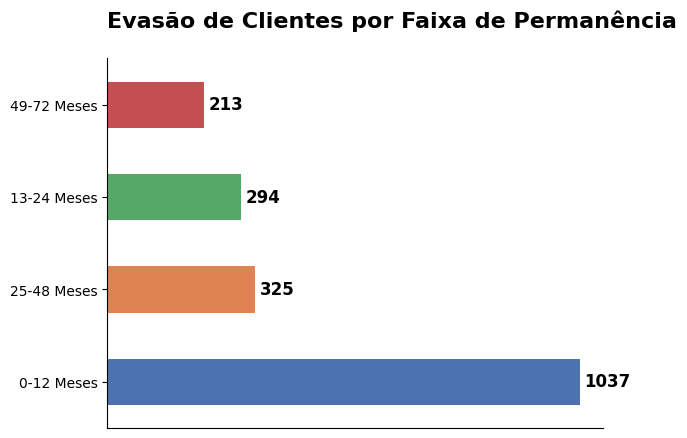

In [639]:
COLOR = sns.color_palette('deep', 4)

ticks = {
    '0-12 meses' : '0-12 Meses',
    '25-48 meses': '25-48 Meses',
    '13-24 meses': '13-24 Meses',
    '49-72 meses': '49-72 Meses'
}

ax = evasao_permanencia.plot(kind='barh', color=COLOR)

for i, v in enumerate(evasao_permanencia):
    ax.text(v + 10, i, f'{v}', va='center', fontweight='bold', fontsize=12)

plt.title('Evasão de Clientes por Faixa de Permanência\n', fontweight='bold', fontsize=16, loc='left')

# pegar apenas o segundo nível do índice (tipo_internet)
ax.set_yticklabels([ticks[i] for i in evasao_permanencia.index])

ax.get_xaxis().set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('')
plt.ylabel('')


plt.show()

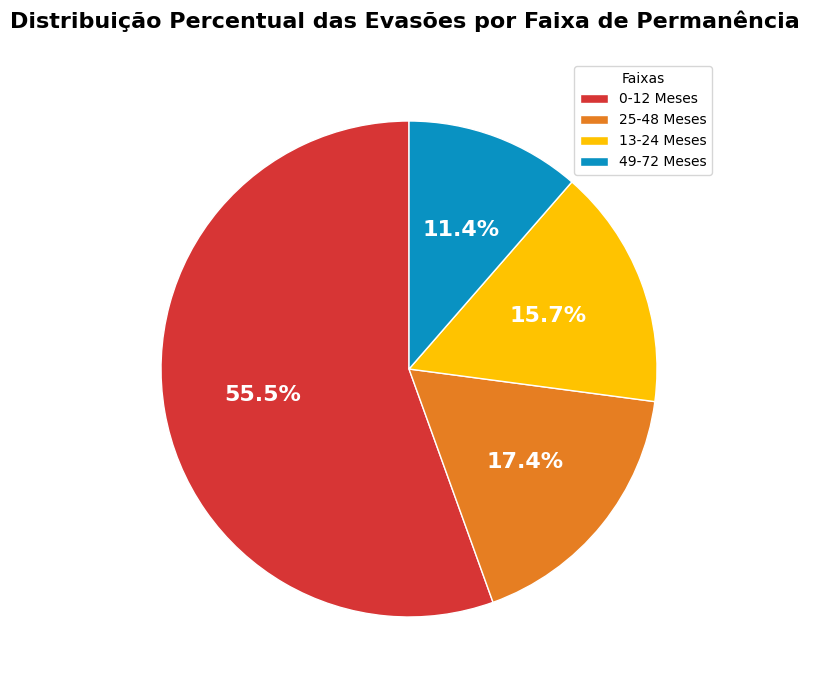

In [640]:
# config de tamanho do grafico
fig, ax = plt.subplots(figsize=(8,18))

ticks = {
    '0-12 meses' : '0-12 Meses',
    '25-48 meses': '25-48 Meses',
    '13-24 meses': '13-24 Meses',
    '49-72 meses': '49-72 Meses'
}


colors = {
    '0-12 meses' : '#D73535',
    '25-48 meses' : '#E67E22',
    '13-24 meses' : '#FFC300',
    '49-72 meses': '#0992C2'
}

# Visual de pizza
evasao_permanencia_relevancia.plot(
    kind='pie',
    labels = [ticks[i] for i in evasao_permanencia_relevancia.index],
    ax=ax,
    startangle=90,
    autopct='%1.1f%%',
    colors= [colors[i] for i in evasao_permanencia_relevancia.index],
    pctdistance=0.6,      # posição da porcentagem
    labeldistance=1.05,   # posição do rótulo
    wedgeprops={'edgecolor':'white','linewidth':1},
    textprops={'fontsize':16,
               'fontweight': 'bold',
               'color' : 'white'},
)

ax.set_title(
    'Distribuição Percentual das Evasões por Faixa de Permanência \n',
    fontsize=16,
    weight='bold'
)

ax.set_ylabel('')  # remove label lateral
plt.legend(loc='upper right', title='Faixas')
plt.show()

#### **Insight**

A maioria da evasão dos clientes se encontra nos **primeiros 12 meses** de contrato com **``55,5%``** das evasões, o que significa uma maior vulnerabiliade em retenção nos primeiro meses de contrato.

Os anos seguintes retem uma quantidade menor de evasão com **``17,4%``** na faixa de **25-48 meses**, **``15,7%``** na faixa de **13-24 meses**, **``11,4%``** na faixa de **49-72 meses**.

Portanto, os primeiros meses são determinantes para lucrar com renovações de contrato, já que a maioria das evasões são por contratos mensais como visto anteriormente.

---

#### **Análise financeira de evasão por cobrança mensal**

In [641]:
clientes_evadidos['cobranca_mensal'].sum()

np.float64(139130.85)

#### **Análise financeira de evasão por cobrança diária**

In [642]:
clientes_evadidos['cobranca_diaria'].mean()

np.float64(2.481449973247726)

#### **Análise financeira de evasão por cobrança total**

In [643]:
clientes_evadidos['cobranca_total'].sum()

np.float64(2862926.9000000004)

### **Análise de Correlação entre Variáveis**

In [644]:
clientes_evadidos.columns

Index(['evasao', 'genero', 'idoso', 'possui_parceiro', 'possui_dependentes',
       'tempo_permanencia', 'servico_telefone', 'multiplas_linhas',
       'tipo_internet', 'seguranca_online', 'backup_online',
       'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv',
       'streaming_filmes', 'tipo_contrato', 'fatura_digital',
       'metodo_pagamento', 'cobranca_mensal', 'cobranca_total',
       'cobranca_diaria', 'faixa_permanencia'],
      dtype='str')

In [645]:
numericas = [
    'tempo_permanencia',
    'cobranca_mensal',
    'cobranca_total',
    'cobranca_diaria'
]

In [646]:
correlation_matrix = clientes_evadidos[numericas].corr()
correlation_matrix

,tempo_permanencia,cobranca_mensal,cobranca_total,cobranca_diaria
tempo_permanencia,1.000000,0.401286,0.954017,0.401425
cobranca_mensal,0.401286,1.000000,0.545772,0.999993
cobranca_total,0.954017,0.545772,1.000000,0.545875
cobranca_diaria,0.401425,0.999993,0.545875,1.000000


In [647]:
corr = dados_normalizados_ml.corr()
corr

,evasao,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,tipo_internet_sem_internet,tipo_contrato_bienal,tipo_contrato_mensal,metodo_pagamento_cheque_correio,metodo_pagamento_cheque_eletronico,metodo_pagamento_transferencia_bancaria_automatica,faixa_permanencia_0-12 meses,faixa_permanencia_13-24 meses,faixa_permanencia_25-48 meses,faixa_permanencia_49-72 meses
evasao,1.000000,0.146733,-0.148546,-0.161384,-0.344079,0.012571,0.039343,-0.166828,-0.080163,-0.063452,...,-0.224051,-0.295138,0.395584,-0.090061,0.294626,-0.114767,0.308907,0.022643,-0.074319,-0.257528
idoso,0.146733,1.000000,0.022970,-0.212952,0.018187,0.010060,0.144567,-0.037953,0.068824,0.060358,...,-0.182697,-0.114837,0.136871,-0.154216,0.170705,-0.015747,-0.030115,0.000029,0.022215,0.009958
possui_parceiro,-0.148546,0.022970,1.000000,0.448900,0.377551,0.018828,0.141187,0.141392,0.139523,0.153209,...,0.000419,0.246472,-0.277828,-0.097648,-0.079629,0.109090,-0.302892,-0.046999,0.029060,0.310605
possui_dependentes,-0.161384,-0.212952,0.448900,1.000000,0.159892,-0.003863,-0.027894,0.083951,0.023686,0.014797,...,0.142274,0.203136,-0.230598,0.060222,-0.151749,0.050923,-0.143118,0.000317,0.024663,0.119955
tempo_permanencia,-0.344079,0.018187,0.377551,0.159892,1.000000,0.010205,0.331678,0.327252,0.361291,0.361792,...,-0.037029,0.557675,-0.647138,-0.234305,-0.207056,0.240732,-0.756479,-0.233676,0.084421,0.852732
servico_telefone,0.012571,0.010060,0.018828,-0.003863,0.010205,1.000000,0.280379,-0.093341,-0.052165,-0.073033,...,0.173109,0.003888,-0.002201,-0.002225,0.004788,0.007406,-0.008662,0.015440,-0.017373,0.012607
multiplas_linhas,0.039343,0.144567,0.141187,-0.027894,0.331678,0.280379,1.000000,0.098396,0.205156,0.202172,...,-0.209917,0.106277,-0.089742,-0.226920,0.085968,0.074701,-0.263685,-0.041890,0.023239,0.272985
seguranca_online,-0.166828,-0.037953,0.141392,0.083951,0.327252,-0.093341,0.098396,1.000000,0.286432,0.275699,...,-0.333690,0.190133,-0.245052,-0.082685,-0.110953,0.093293,-0.241084,-0.055387,0.005639,0.276503
backup_online,-0.080163,0.068824,0.139523,0.023686,0.361291,-0.052165,0.205156,0.286432,1.000000,0.306665,...,-0.382331,0.107426,-0.164761,-0.174118,0.000933,0.081597,-0.268478,-0.082587,0.022921,0.308710
protecao_dispositivo,-0.063452,0.060358,0.153209,0.014797,0.361792,-0.073033,0.202172,0.275699,0.306665,1.000000,...,-0.380818,0.163317,-0.225491,-0.187456,-0.000063,0.078782,-0.273786,-0.077013,0.044376,0.290494


In [648]:
corr_evasao = corr['evasao'].sort_values(ascending=False)
corr_evasao

evasao                                                1.000000
tipo_contrato_mensal                                  0.395584
faixa_permanencia_0-12 meses                          0.308907
tipo_internet_fibra_optica                            0.300949
metodo_pagamento_cheque_eletronico                    0.294626
cobranca_diaria                                       0.189918
cobranca_mensal                                       0.189866
fatura_digital                                        0.186666
idoso                                                 0.146733
streaming_tv                                          0.062430
streaming_filmes                                      0.060586
multiplas_linhas                                      0.039343
faixa_permanencia_13-24 meses                         0.022643
servico_telefone                                      0.012571
genero_masculino                                     -0.009555
protecao_dispositivo                                 -0

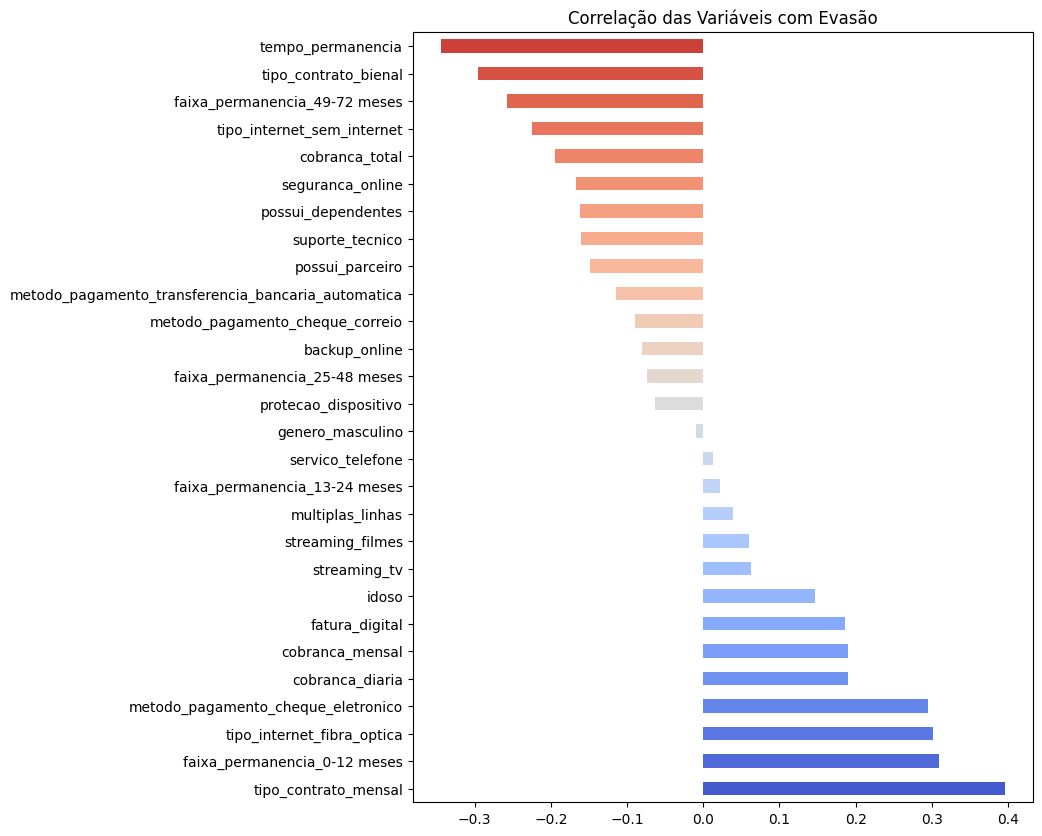

In [649]:
corr_evasao.drop('evasao').plot(
    kind='barh',
    figsize=(8,10),
    color= sns.color_palette('coolwarm',29)
)

plt.title('Correlação das Variáveis com Evasão')
plt.show()

### **Insight**

O gráfico de barras representa o grau de correlação entre as demais variáveis da base de dados com a variável de **evasão**.

Para a base de dados **TelecomX**, as variáveis:
 
 - ``tipo_contrato_mensal``
 - ``tipo_internet_fibra_optica``
 - ``metodo_pagamento_cheque_eletronico``
 - ``faixa_permanencia_0-12 meses`` 
 
 Contém mais relação com evasão do que variáveis como: 
 
 - ``tipo_contrato_bienal`` 
 - ``faixa_permanencia_49-72 meses`` 
 - ``tipo_internet_sem_internet`` 
 
 Com valores correlacionais negativos indicando baixa relação com a variável evasão.

 Os valores positivos do gráfico de correlação indicam relacionamento maior para com a evasão de cliente.

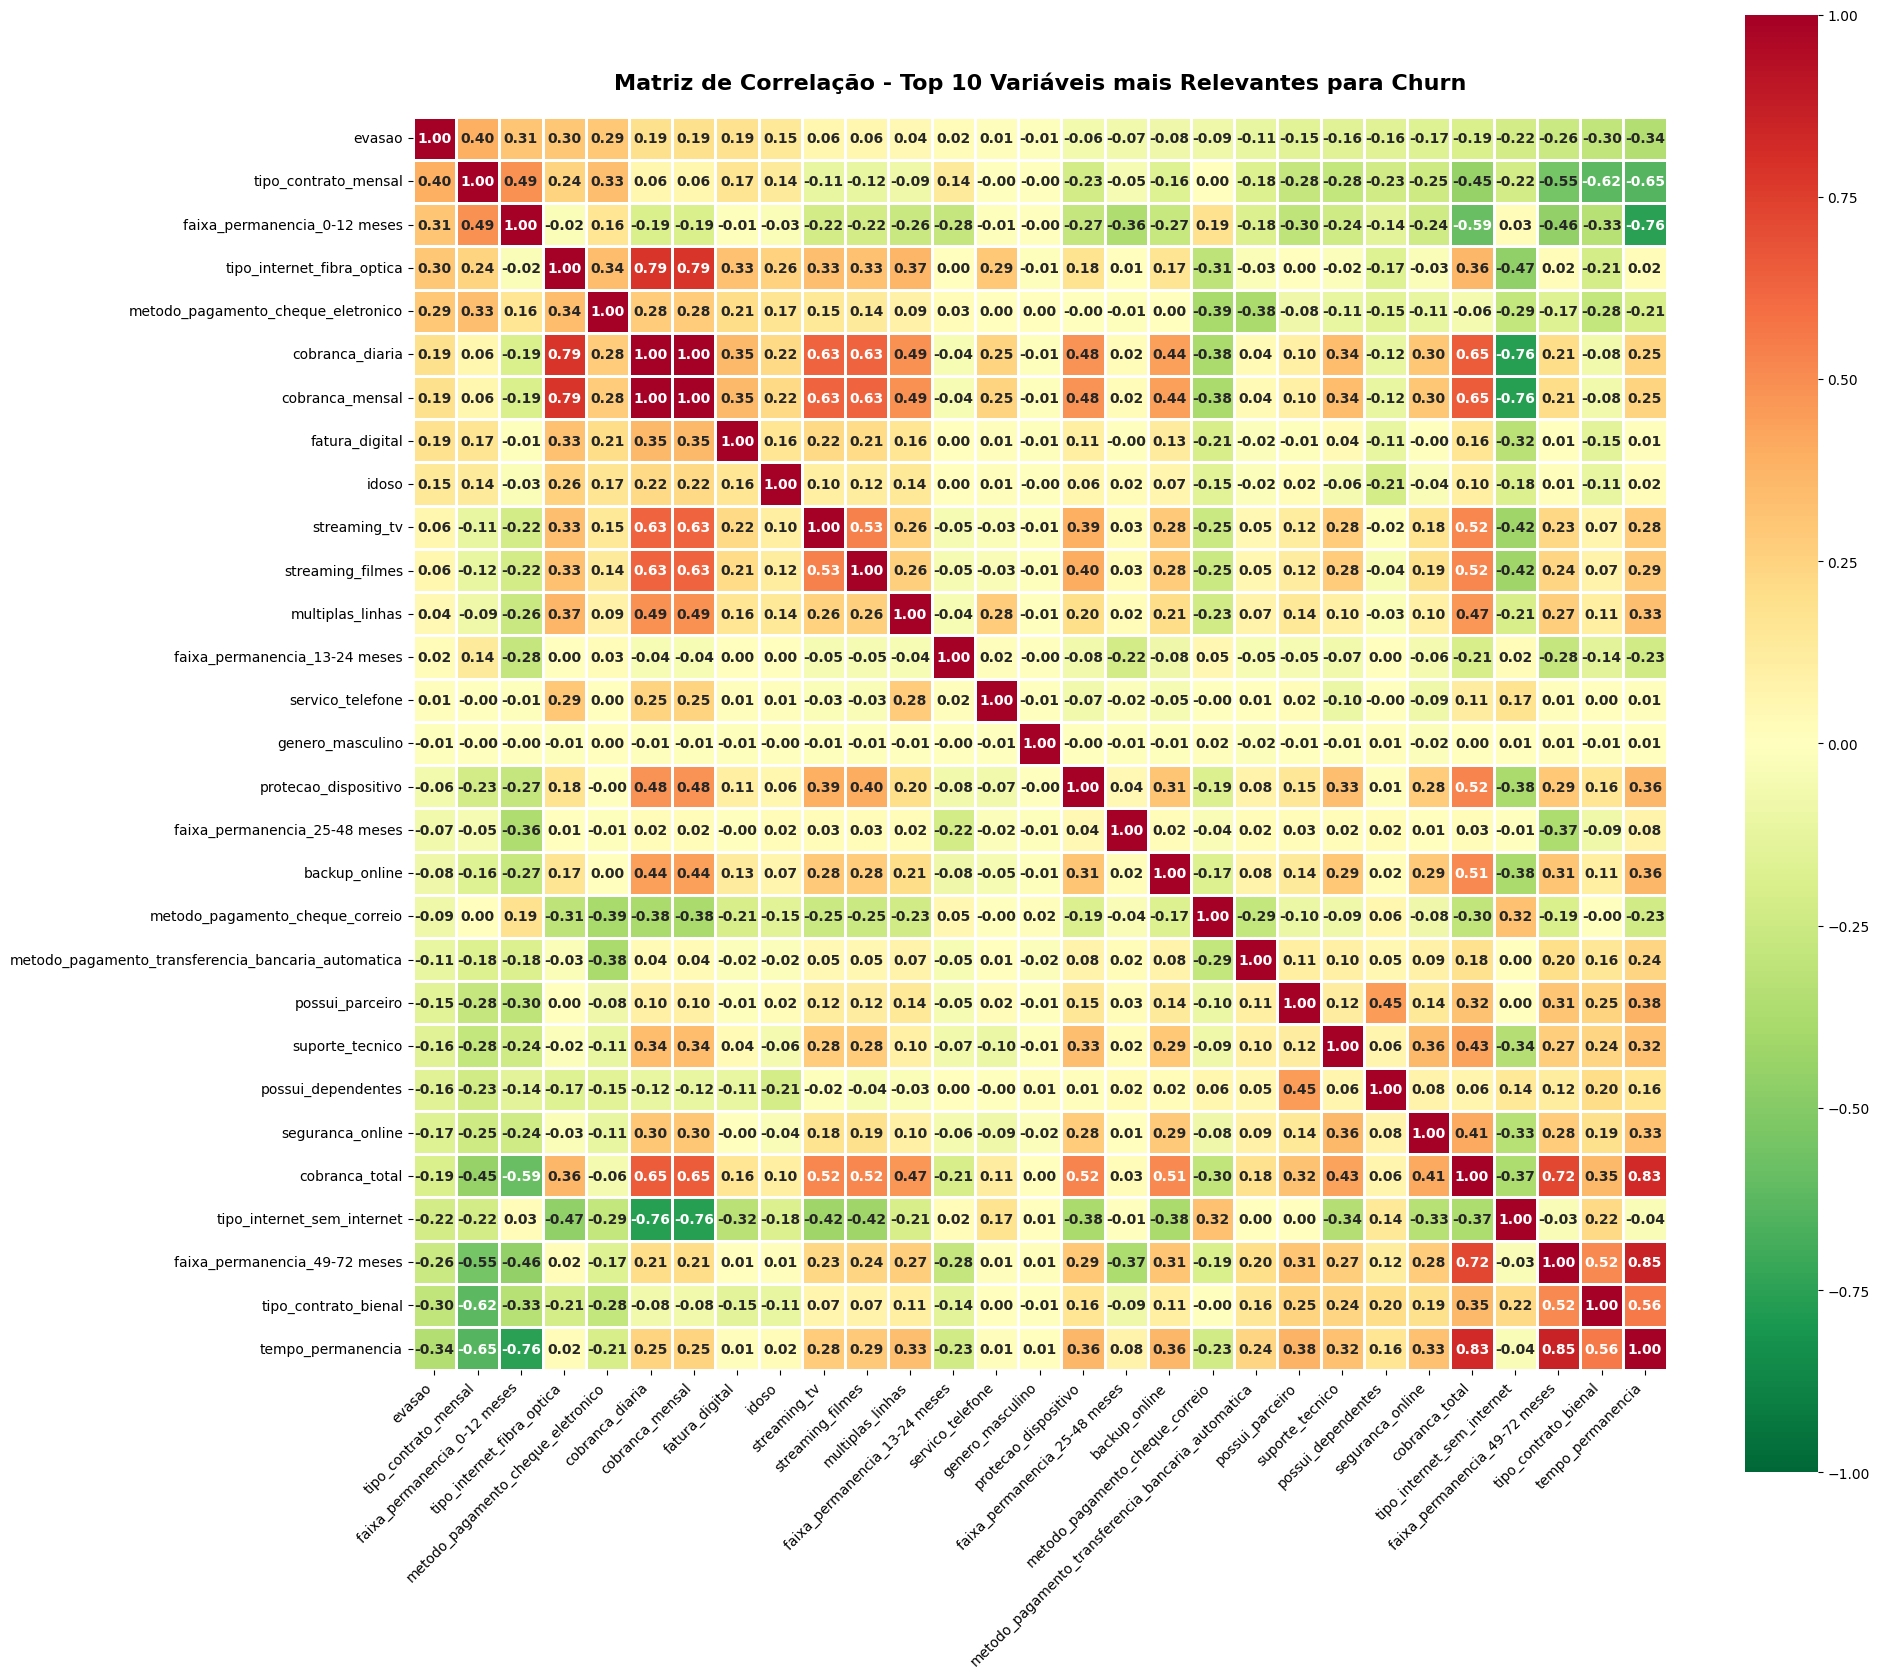

In [653]:
top_vars = corr_evasao.index

# 4️⃣ Criar a matriz quadrada apenas com essas variáveis
corr_evasao_vars = corr.loc[top_vars, top_vars]

# 5️⃣ Plotar o heatmap (seu código)
plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_evasao_vars,
    annot=True,
    fmt='.2f',
    annot_kws={"size": 10, "weight": "bold"},
    cmap='RdYlGn_r',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1
)

plt.title(
    'Matriz de Correlação - Top 10 Variáveis mais Relevantes para Churn',
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

### **Insights**

Nesse Gráfico de correlação é possivel visualizar o valor de correlação entre as variáveis reforçando as metricas vistas anteriormente no gráfico de barras.

Valores com o vermelho mais **forte** reforçam a visualização e indicam maior relação.

---


# 📄 **Relatorio Final**

Este relatório apresenta uma análise exploratória dos dados de clientes da **``TelecomX``**, com o objetivo de identificar padrões associados à **evasão de clientes**. A análise buscou compreender características comportamentais e contratuais dos clientes que cancelaram seus serviços, apoiando futuras estratégias de retenção e desenvolvimento de modelos preditivos.

O conjunto de dados contém algumas **informações demográficas**, **serviços contratados**, **tipo de contrato**, **forma de pagamento** e **valores de cobrança.**

A variável alvo da análise é **``evasao``**, que indica se o cliente cancelou ou não os serviços.

### 📌 **Extração e Transformação** 

A primeira etapa do projeto consistiu em importar a base de dados em ``.json`` e trata-los para as análise posteriores.

Com a **``importação``** dos dados, as colunas foram transformadas em dataframes separados em razão da normalização e reúnidos logo após em um único dataframe, finalizando a etapa de importação dos dados.

Após a etapa de coleta e organização dos dados, iniciou-se o processo de **`limpeza`** e **`normalização`** da base.

Durante essa etapa, foram realizadas substituições de caracteres, adequação dos tipos de dados das colunas e a tradução dos nomes das variáveis para **Português**, com o objetivo de facilitar a interpretação e análise das informações.

- Como etapa EXTRA no projeto:

Foi adicionado a coluna de ``cobrança_diaria`` ao dataset para informatizar melhor a base para a etapa de treino de modelos de machine learning

Também foi criada uma versão da base de dados do projeto para o treinamento de modelos de **Machine Learning**. 

Nessa etapa, as variáveis categóricas foram transformadas em valores binários (**`0`** e **`1`**) utilizando a técnica de **`One-Hot Encoding`**. o que facilita o treino de modelos. 

### 📌 **Análise Exploratória dos Dados** 

Nesta etapa, foram realizadas análises descritivas, informativas e visuais com o objetivo de compreender a distribuição das variáveis, identificar padrões nos dados e investigar possíveis relações com a variável de evasão de clientes.

As etapas de análise realizadas no projeto foram:

- ***1. Distribuição Geral da Evasão***

- ***2. Perfil Demográfico dos Clientes***

- ***3. Perfil Contratual dos Clientes***

- ***4. Serviços Contratados pelos Clientes***

- ***5. Perfil de Consumo e Pagamento***

- ***6. Análise Financeira***

- ***7. Análise de Correlação***


- Os **insights** obtidos das etapas de análise exploratória dos dados foram:

### 📊 **Distribuição da Evasão**

- A análise inicial mostra que exatamente **1869** clientes cancelaram seus serviços, representando uma parcela relevante da base analisada.

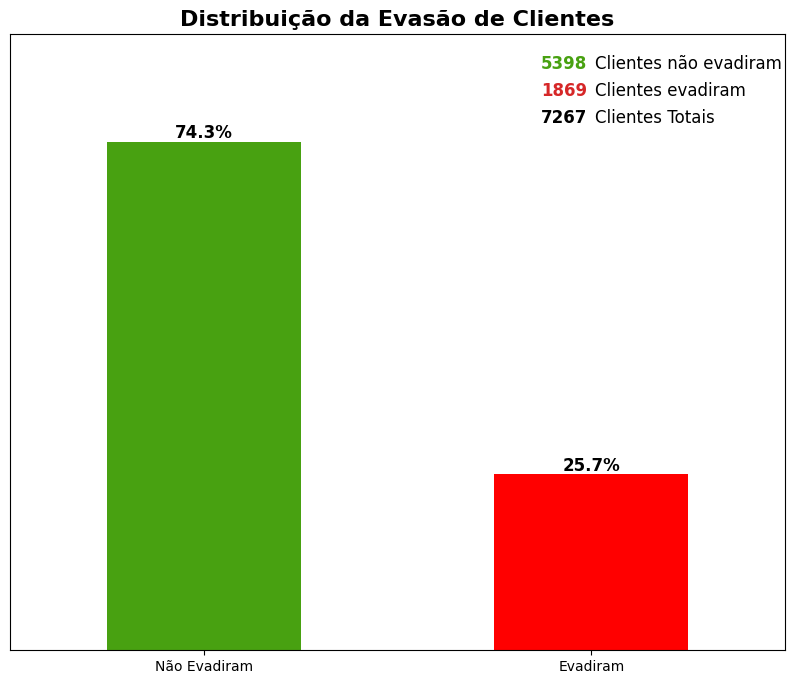

### 📊 **Evasão por tipo de Serviço de internet**

- O serviço de internet é uma das variáveis com mais relação com a evasão, o serviço de Internet por Fibra óptica possui a maior distribuição de evasões.

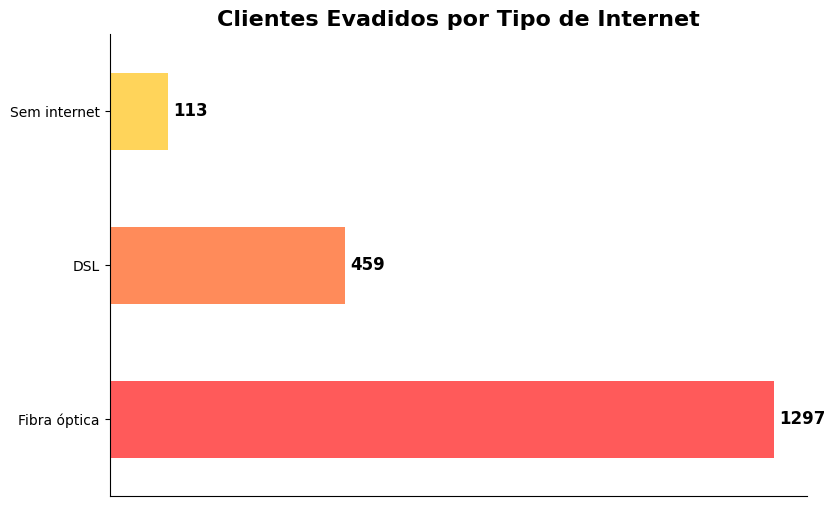

### 📊 **Evasão por Gênero**

- A distribuição das evasões por gênero é praticamente equilibrada, com cerca de **``50%``** para cada grupo, o que indica que o gênero não apresenta um padrão claro associado ao churn.

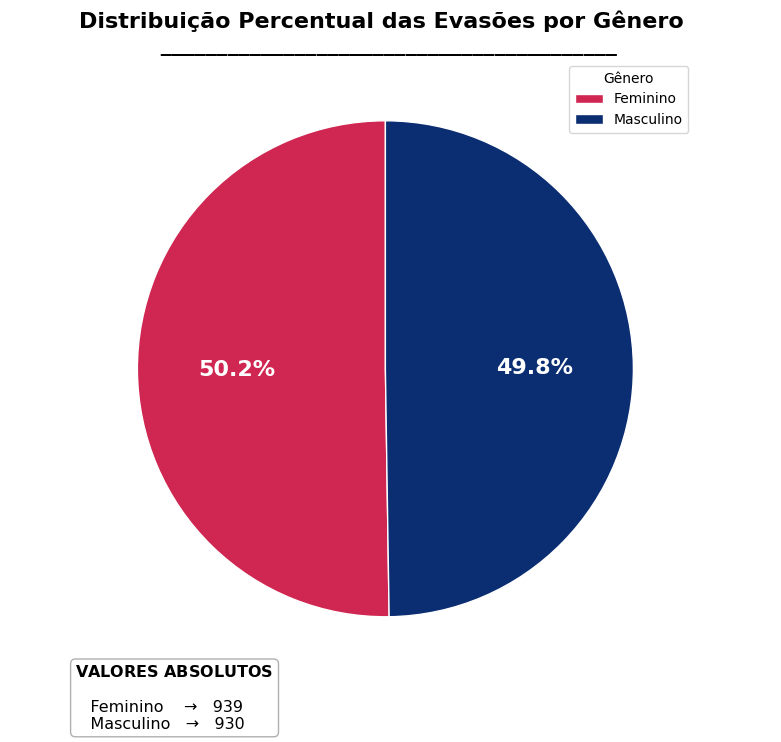

### 📊 **Evasão por Sênioridade**

- A análise por sênioridade mostra que **``74,5%``** das evasões ocorreram entre clientes não idosos, enquanto **``25,5%``** correspondem a clientes com mais de 60 anos.

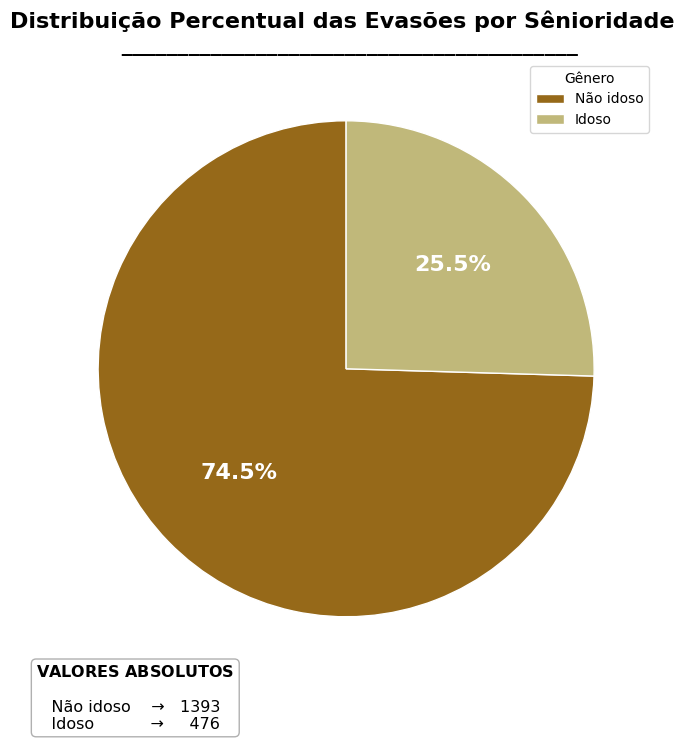

### 📊 **Evasão por Tipo de Contrato**

- Esse é um dos insights mais fortes.

- A maior parte das evasões ocorre entre clientes com contratos mensais, representando **``88,5%``** (**1655** clientes) dos cancelamentos.
Em comparação, contratos anuais representam **``8,8%``** (**166** clientes), enquanto contratos bienais representam apenas **``2,5%``** (**48** clientes) .

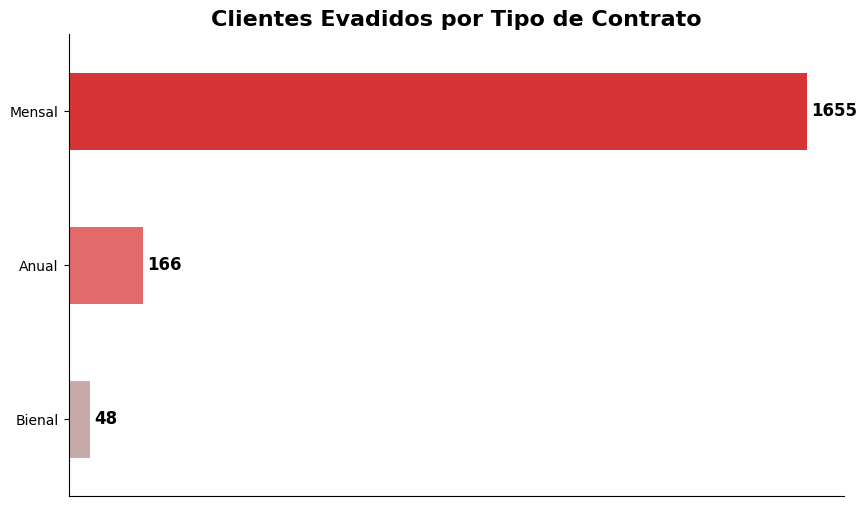
 

- Foi tirado também o impacto financeiro de **R$ 2,862,926.90** que as evasões causam no faturamento.

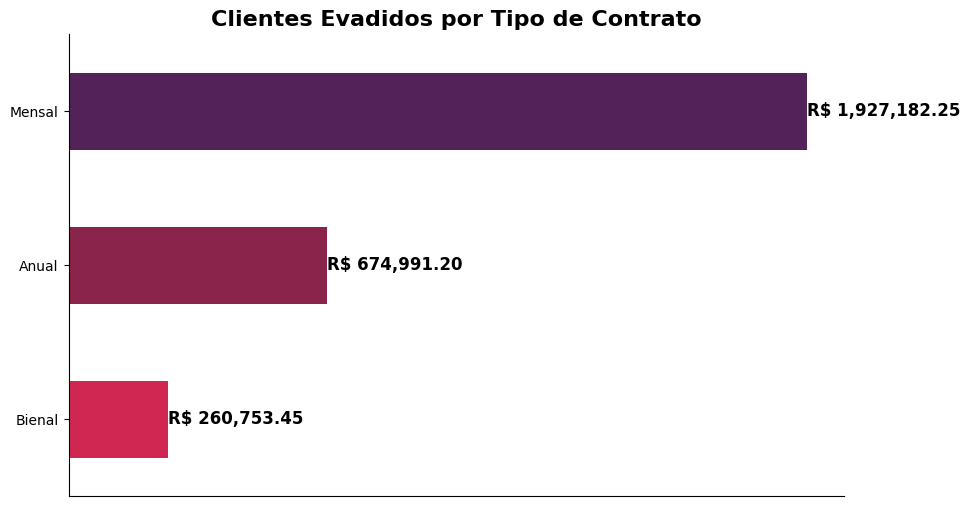

- Isso indica que contratos de curta duração apresentam menor capacidade de retenção de clientes.

### 📊 **Evasão por Faixa de Permanência**

- Obtida as distribuições de evasões por faixa de permanência de contrato, cliente tendem a evadir nos primeiro 12 meses de vínculo.

- A média de permanencia do cliente é **``17.9``** meses, ou seja, até aproximadamente **``18 meses``** o cliente cancela o contrato de serviço

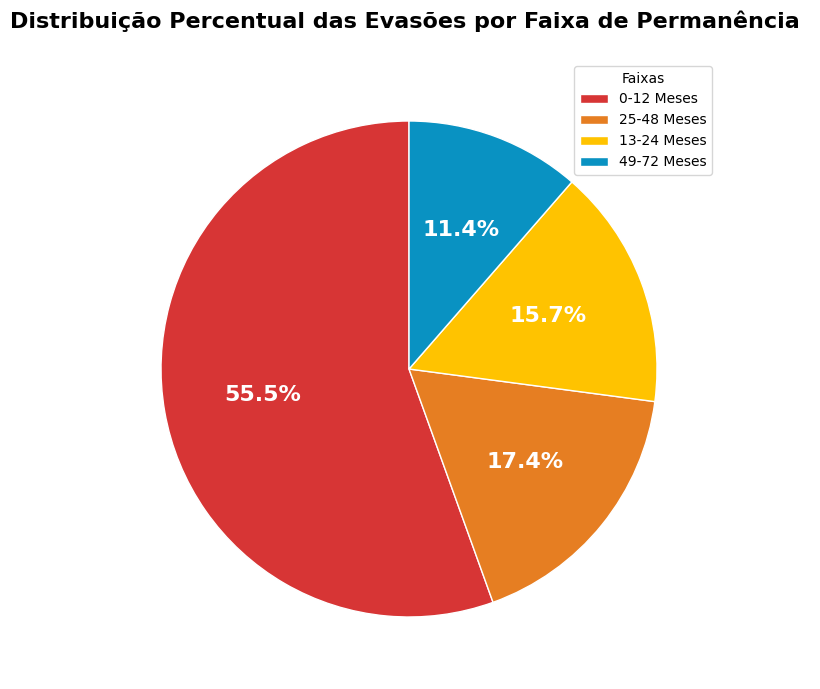

### 📊 **Evasão por Serviços Contratados**

- Entre os clientes que cancelaram seus serviços:

- **``90,9%``** possuíam serviço de telefone

- **``45,5%``** possuíam múltiplas linhas

- **``43,8%``** possuíam streaming de filmes

- **``43,6%``** possuíam streaming de TV

- Como um cliente pode possuir múltiplos serviços simultaneamente, os valores representam a presença de cada serviço entre os clientes evadidos.

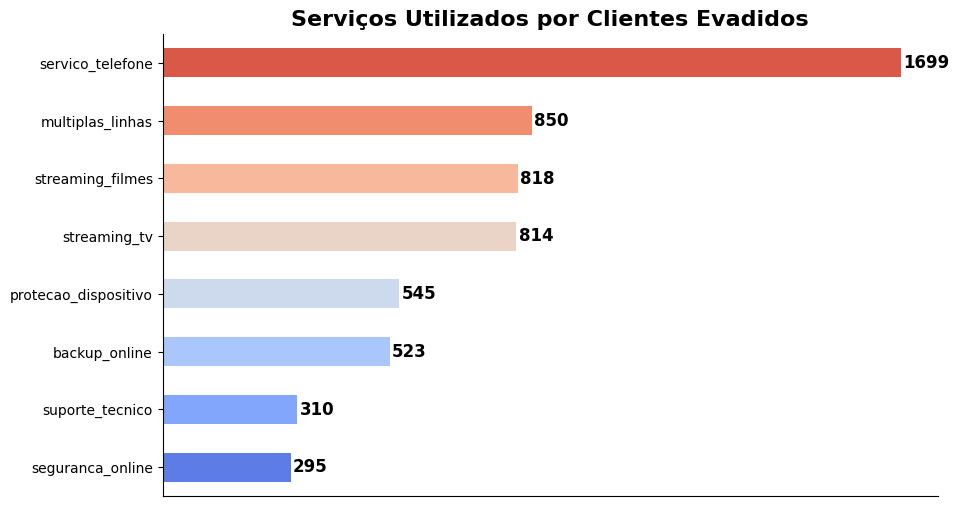

### 📊 **Evasão por Método de Pagamento**

- A maior concentração de evasões ocorre entre clientes que utilizam cheque eletrônico, representando **``57,3%``** dos cancelamentos.

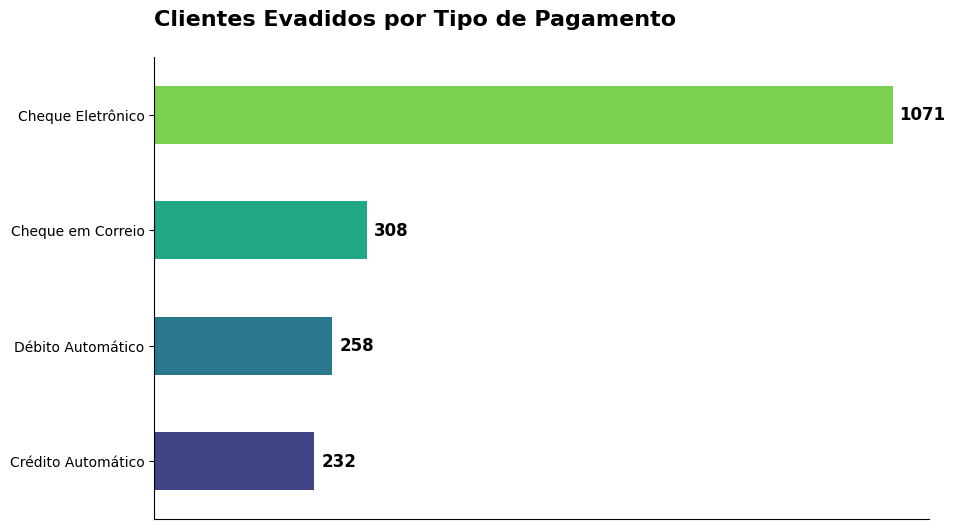

### 📊 **Evasão por Perfil Familiar**

- Observa-se que **``82,6%``** das evasões ocorrem entre clientes que não possuem dependentes, enquanto **``64,2%``** ocorrem entre clientes que não possuem parceiros.

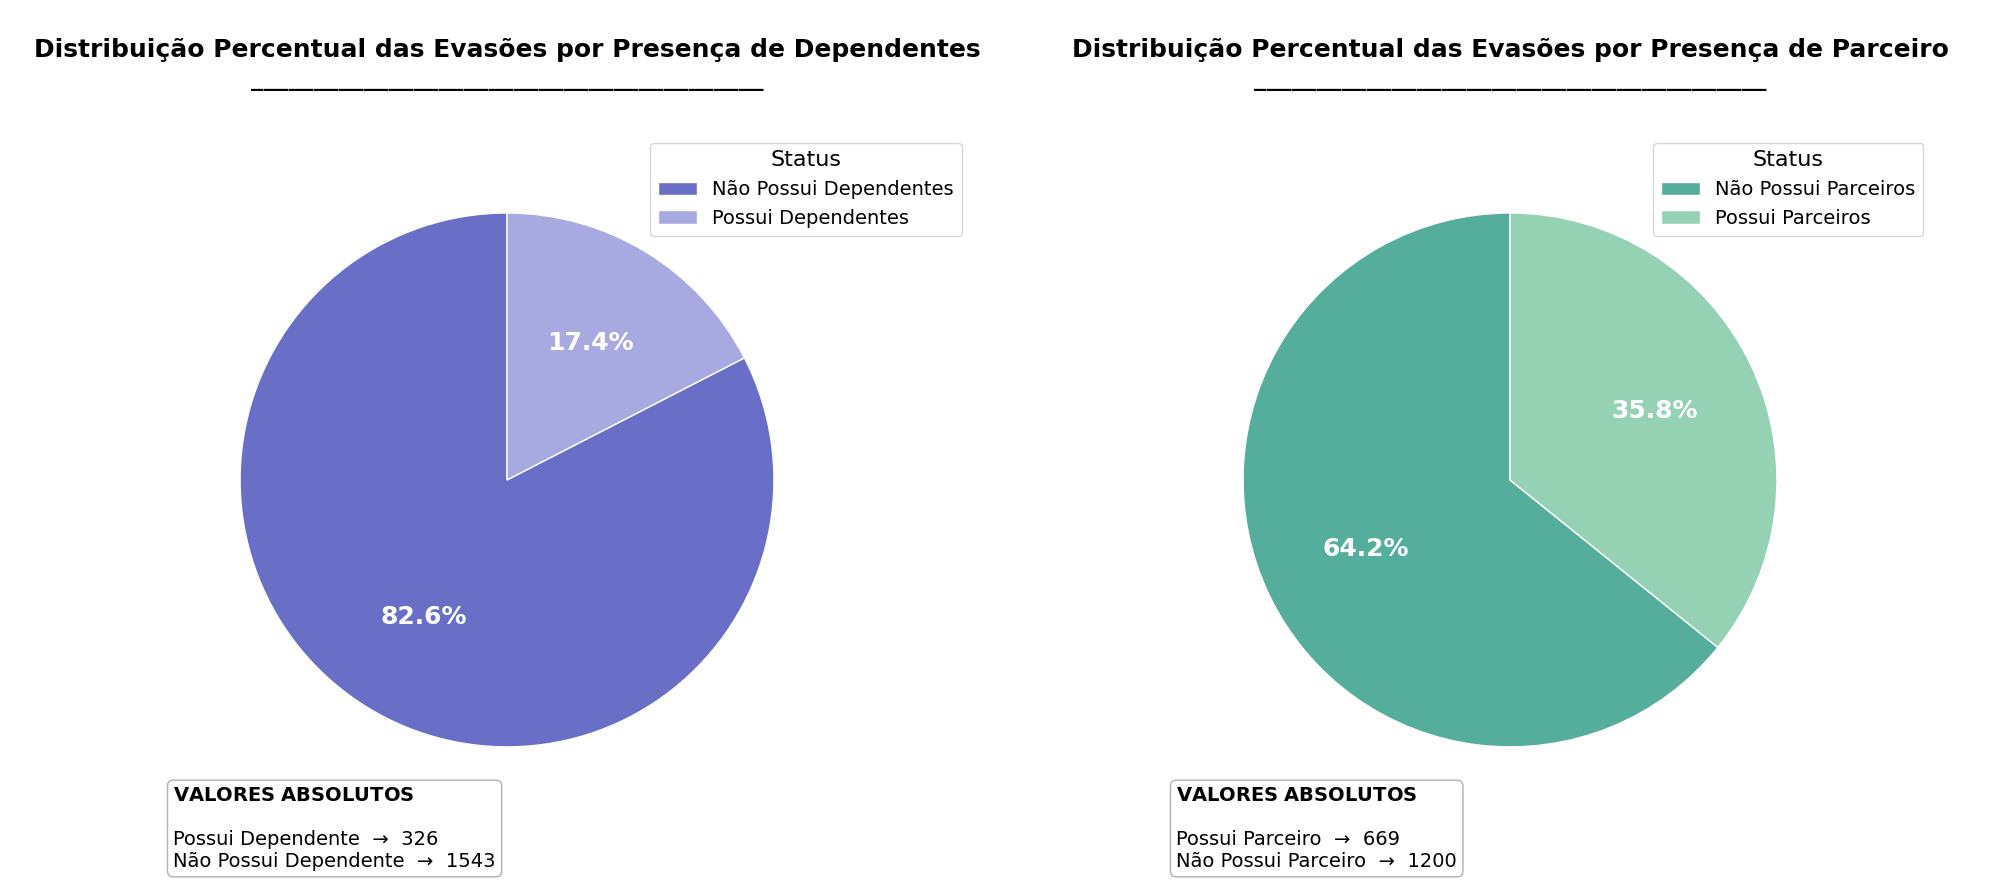



### 📊 **Análise de Correlação**


- A normalização dos dados em códigos binários com o **``OneHotEncoding``** foi útil para servir como base de dados do gráfico de correlação, dados numerais trabalham melhor em gráficos como o de correlação 

- Foi construída uma matriz de correlação para identificar relações entre variáveis numéricas e a variável de evasão.

- Os resultados indicam que variáveis como tempo de permanência, tipo de contrato e cobrança mensal apresentam maior associação com o churn.

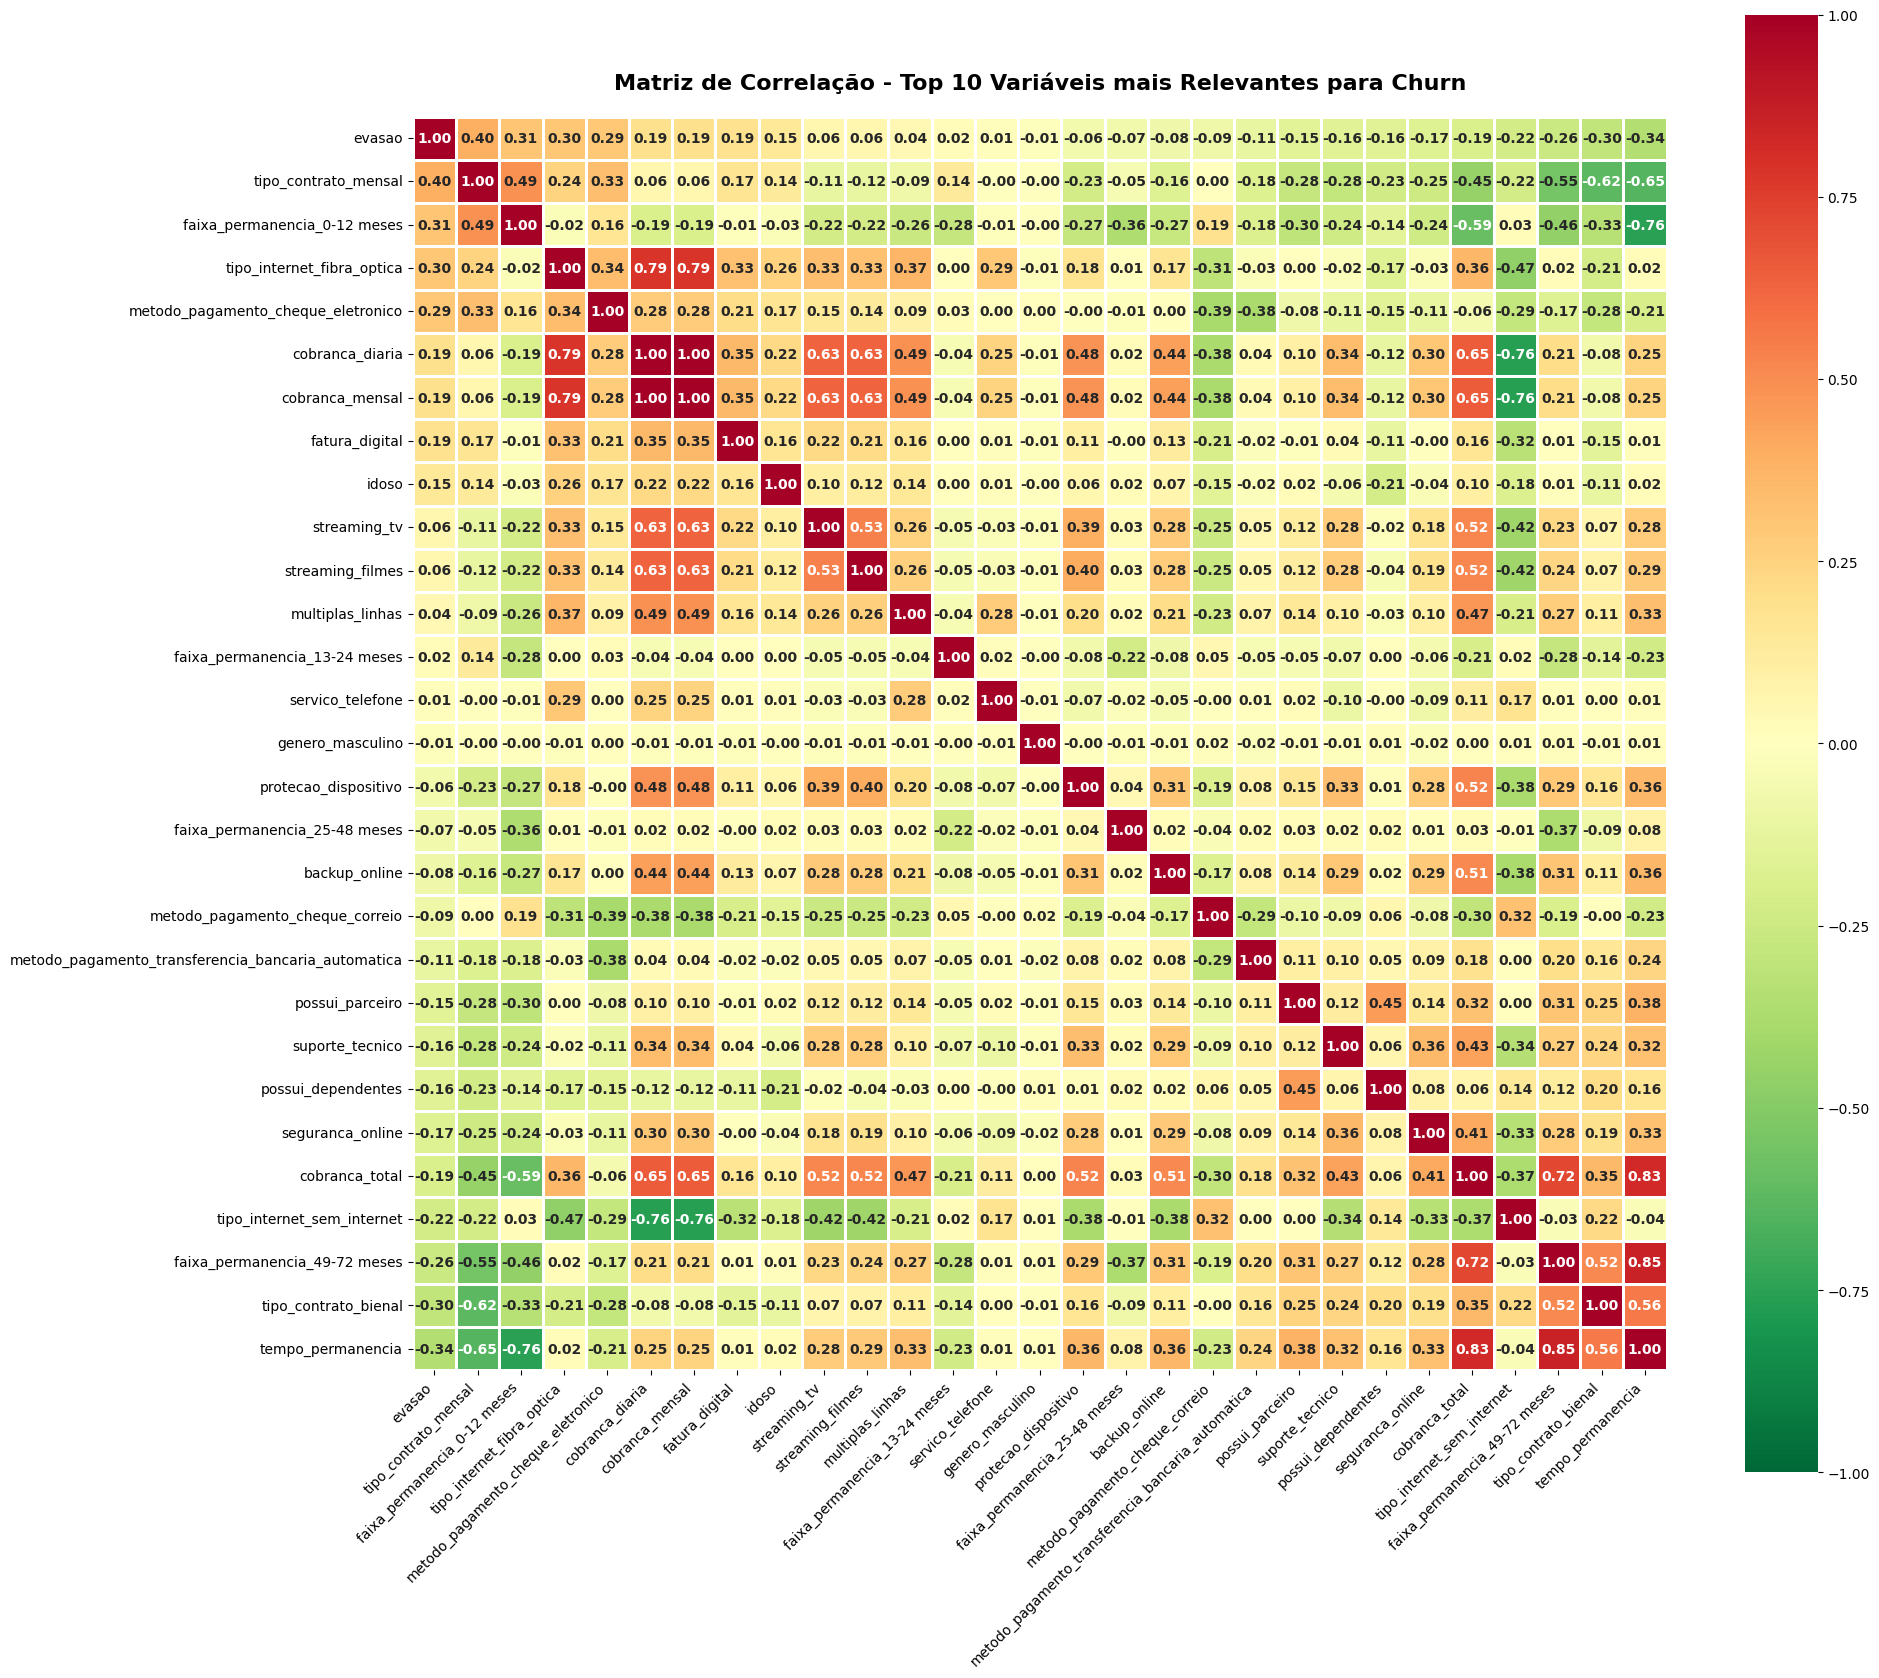


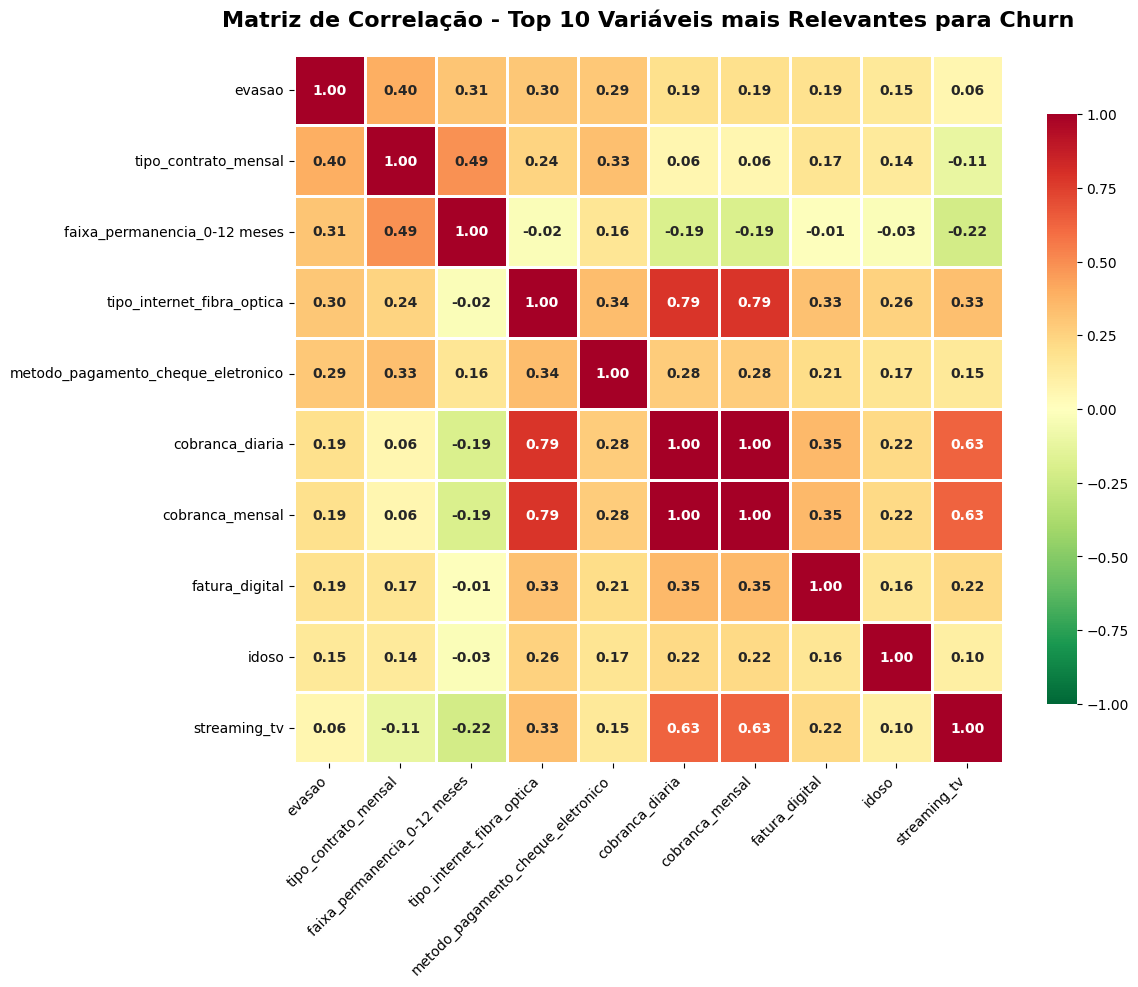

# 📌 **Conclusão**

A análise exploratória revelou padrões importantes associados à evasão de clientes na **TelecomX**. 

Destacam-se principalmente o impacto do ``tipo de contrato``, do ``método de pagamento`` e da ``senioridade``


**``Insights``**

- Contratos mensais possuem mais chances de evasão 

- Pagamentos com a modalidade cheque eletronico tendem a fazer o cliente cancelar contrato

- Clientes que não são idosos, somam a maior parcelas de evasões
 
- Primeiros meses de contrato possuem maior chance de evasão 

- Serviços de Fibra óptica possuem uma taxa de cancelamento elevada 


Esses são os principais **insights** que leva a responder os números de evasões que a ``**TelecomX**`` tem.

**``Chamado a Ação``** 

- **Incentivar contratos de maior duração**, oferecendo benefícios ou descontos para clientes que optarem por planos anuais ou bienais.

- **Promover métodos de pagamento automáticos**, como débito automático ou cartão de crédito, reduzindo a dependência de pagamentos manuais.

- **Criar estratégias de retenção nos primeiros meses de contrato**, como programas de acompanhamento do cliente ou benefícios iniciais.

- **Investigar a experiência dos clientes com o serviço de fibra óptica**, buscando identificar possíveis fatores de insatisfação relacionados à qualidade do serviço ou suporte técnico.

- 👀 **Utilizar modelos de Machine Learning** para prever clientes com maior probabilidade de evasão, permitindo ações preventivas e campanhas de retenção mais direcionadas.

---

A aplicação dessas estratégias pode contribuir para melhorar a retenção de clientes, reduzir perdas financeiras associadas ao ``churn`` e apoiar decisões mais orientadas por dados dentro da **TelecomX**.

